In [ ]:
!python lip-movement-net/src/lip_movement_net.py -v lip-movement-net/videos/044598381-carl-rowan-delivering-speech-a.mp4 -p lip-movement-net/models/shape_predictor_68_face_landmarks.dat -m lip-movement-net/models/1_32_False_True_0.25_lip_motion_net_model.h5

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install mediapipe opencv-python
!apt-get install ffmpeg

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 43.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.6/294.6 kB 37.7 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 3.20.3
    Uninstalling protobuf-3.20.3:
      Successfully uninstalled protobuf-3.20.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-metadata 1.15.0 requires protobuf<4.21,>=3.20.3; python_version < "3.11", but you have protobuf 4.25.3 which is incompatible.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 45 not upgraded.


In [ ]:
!pip3 install absl-py
!pip3 install attrs
!pip3 install cycler
!pip3 install fonttools
!pip3 install kiwisolver
!pip3 install matplotlib
!pip3 install mediapipe
!pip3 install numpy
!pip3 install opencv-contrib-python
!pip3 install opencv-python
!pip3 install packaging
!pip3 install Pillow
!pip3 install protobuf
!pip3 install pyparsing
!pip3 install python-dateutil
!pip3 install setuptools-scm
!pip3 install six
!pip3 install tomli
!pip3 install tensorflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.9 MB/s eta 0:00:00


In [ ]:
# change frame per second
import os
def change_fps(input_video_path, output_video_path, new_fps): os.system(f'ffmpeg -i {input_video_path} -r {new_fps} -filter:v fps=fps={new_fps} {output_video_path}')
# Example usage:
input_video_path = '/content/drive/MyDrive/lipmovement/doardohat.mp4' # Change this to your input video file path
output_video_path = '/content/drive/MyDrive/lipmovement/office3.mp4' # Change this to your desired output video file path
new_fps = 10 # Change this to your desired new frame rate
change_fps(input_video_path, output_video_path, new_fps)

In [ ]:
# read video and creat frame in especial folder
import cv2

capture = cv2.VideoCapture('/content/drive/MyDrive/lipmovement/office3.mp4')

fps = capture.get(cv2.CAP_PROP_FPS)
frameNr = 0

while (True):

    success, frame = capture.read()

    if success:
        cv2.imwrite(f'/content/drive/MyDrive/lipmovement/inputpic/office3/office{frameNr}.jpg', frame)

    else:
        break

    frameNr = frameNr+1

capture.release()
print(fps)

10.0


In [ ]:
#find floor of room
import cv2
import mediapipe as mp
import numpy as np
from keras.models import model_from_json
#read first frame
#image = cv2.imread("/content/drive/MyDrive/calibration/frame detect3/frame_0.jpg")
image = cv2.imread("/content/drive/MyDrive/paper pic/lip movement/test_0.jpg")


h, w, c = image.shape
print('width:  ', w)
print('height: ', h)
print('channel:', c)
# find squres
blur = cv2.pyrMeanShiftFiltering(image, 90, 90)
gray = cv2.cvtColor(blur, cv2.COLOR_BGR2GRAY)
thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)[1]
cv2.imwrite(f'/content/drive/MyDrive/lipmovement/p2.jpg', thresh)
cnts = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cnts = cnts[0] if len(cnts) == 2 else cnts[1]
var = 1
control_pixel=0
for c in cnts:
    peri = cv2.arcLength(c, True)
    approx = cv2.approxPolyDP(c, 0.09 * peri, True)
    if len(approx) == 4:
        x,y,w,h = cv2.boundingRect(approx)
# bar asase andazeye morabaeha az rouye mizane thereshhold w,h,y ra takhmin mizanim,
        if ((w*h)>250 and y>400):
            cv2.rectangle(image,(x,y),(x+w,y+h),(36,255,12),2)
            # find point
            if var == 1:
               x1= x+w
               y1=y+h
               cv2.circle(image, (x1,y1), radius=2, color=(0, 0, 255), thickness=2)
               var+=1
            elif var == 2:
                x2= x
                y2=y+h
                cv2.circle(image, (x2,y2), radius=2, color=(0, 255 , 0), thickness=2)
                var+=1
                control_pixel=w
            elif var == 3:
                x3= x
                y3=y+h
                cv2.circle(image, (x3,y3), radius=2, color=(255, 0, 0), thickness=2)
                var+=1
            elif var == 4:
                 x4= x+w
                 y4=y+h
                 cv2.circle(image, (x4,y4), radius=2, color=(0, 0, 0), thickness=2)





width:   1280
height:  720
channel: 3


In [ ]:
#draw 42 lines
x1=280
x2=980
x3=780
x4=475
y1=670
y2=670
y3=490
y4=490
image = cv2.imread("/content/drive/MyDrive/paper pic/lip movement/test_0.jpg")
cv2.line(image, (x1,y1), (x4,y4), (0,0,255), 2)
cv2.line(image, (x2,y2), (x3,y3), (255,0,0), 2)
cv2.imwrite(f'/content/drive/MyDrive/lipmovement/p1.jpg', image)
image_height, image_width, _ = image.shape

In [ ]:
#face landmarks find for 1 face
import cv2
import mediapipe as mp
import numpy as np
import argparse
import sys
import os
from mediapipe.framework.formats import landmark_pb2
mp_drawing = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles
mp_face_mesh = mp.solutions.face_mesh

IMAGE_FILES = [1]
pixel_landmarks1=[]
counter = 0
frameNr =280
y1=[]
y2=[]
y=[]
s1Mouthy=[]
# change mediapipe type to list

def landmark_list_to_list(landmark_list):
    landmarks = []
    for landmark in landmark_list.landmark:
        landmarks.append((landmark.x, landmark.y, landmark.z))  # Assuming you want x, y, z coordinates
    return landmarks

# change normalized to coordinate
def normalize_to_pixel_coordinates(normalized_x, normalized_y, image_width, image_height):
    """
    Converts normalized landmark coordinates to pixel coordinates.
    """
    pixel_x = int(normalized_x * image_width)
    pixel_y = int(normalized_y * image_height)
    return pixel_x, pixel_y

def landmark_list_to_pixel_coordinates(landmark_list, image_width, image_height):
    """
    Converts a list of normalized landmarks to pixel coordinates.
    """
    pixel_coordinates = []
    for landmark in landmark_list:
        pixel_x, pixel_y = normalize_to_pixel_coordinates(landmark[0], landmark[1], image_width, image_height)
        pixel_coordinates.append((pixel_x, pixel_y))
    return pixel_coordinates


for counter in range(0,5):
    mp_drawing = mp.solutions.drawing_utils
    mp_drawing_styles = mp.solutions.drawing_styles
    mp_holistic = mp.solutions.holistic
    scount=1
    for scount in range(1,2):
        if scount==1:
            # For static images:
            IMAGE_FILES = [1]

            with mp_holistic.Holistic(
                static_image_mode=True,
                model_complexity=2,
                enable_segmentation=True,
                refine_face_landmarks=True) as holistic:

                for idx, file in enumerate(IMAGE_FILES):
                    image = cv2.imread(f'/content/drive/MyDrive/lipmovement/inputpic/1speakerfixe/1sf{frameNr}.jpg')
                    # Convert the BGR image to RGB before processing.
                    results = holistic.process(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
                    landmarks=results.face_landmarks
                    s1mouthy=(f'{results.pose_landmarks.landmark[mp_holistic.PoseLandmark.MOUTH_LEFT].y* image_height}')
                    s1mouthy=round(float(s1mouthy))
                    s1Mouthy.append(s1mouthy)
                    # Assuming landmark_list is your NormalizedLandmarkList object
                    landmark_list1 = results.face_landmarks
                    # Populating landmark_list with your data...
                    # Convert to list
                    landmarks_list1 = landmark_list_to_list(landmark_list1)
                    # Assuming landmark_list is your list of landmarks and image_width, image_height are the dimensions of the image
                    image_height, image_width, _ = image.shape
                    pixel_landmarks1 = landmark_list_to_pixel_coordinates(landmarks_list1, image_width, image_height)
                    y1=np.array(pixel_landmarks1[13])
                    #print('14:', pixel_landmarks1[14,0])
                    #y=(pixel_landmarks1[14]- pixel_landmarks1[13])
                    frameNr=frameNr+1
                    #pixel_landmarks1=round(float(pixel_landmarks1))
                    #pixel_landmarks1.append(pixel_landmarks1)
                    y1=np.array(pixel_landmarks1[13])
                    y2=np.array(pixel_landmarks1[14])
                    y=np.append(y,y1)
                    #print(y1)


s1MouthY = np.asarray(s1Mouthy)
print(type(s1MouthY))









<class 'numpy.ndarray'>


In [ ]:
# Calculate 3 pose estimation  with 3 face landmarks #
import cv2
import mediapipe as mp
import numpy as np
import argparse
import sys
import os
from keras.models import model_from_json
from mediapipe.framework.formats import landmark_pb2

mp_drawing = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles
mp_face_mesh = mp.solutions.face_mesh


#calculate focal length of camera:
room_width=100 #int(input('enter width of room:'))
control_distance=300 #int(input('enter first squre distance:'))
control_width=400 #int(input('enter width of control box:'))
control_pixel=0
focal=(control_pixel*control_distance)/control_width
mp_drawing = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles
mp_face_mesh = mp.solutions.face_mesh
default_font = cv2.FONT_HERSHEY_SIMPLEX
drawing_spec = mp_drawing.DrawingSpec(thickness=1, circle_radius=1)
# give selected image from path
x1=280
x2=980
x3=780
x4=475
y1=670
y2=670
y3=490
y4=490

pixel_landmarks1=[]
s1_lower_lip=[]
s1_upper_lip=[]
l1=[]
u1=[]

pixel_landmarks2=[]
s2_lower_lip=[]
s2_upper_lip=[]
l2=[]
u2=[]

pixel_landmarks3=[]
s3_lower_lip=[]
s3_upper_lip=[]
l3=[]
u3=[]

n=615

counter = 0
frameNr =3
s1Px=[]
s1Py=[]
s1Nosex=[]
s1Nosey=[]
s1Mouthx=[]
s1Mouthy=[]
realdistances1=[]
s2Px=[]
s2Py=[]
s2Nosex=[]
s2Nosey=[]
s2Mouthx=[]
s2Mouthy=[]
realdistances2=[]
s3Px=[]
s3Py=[]
s3Nosex=[]
s3Nosey=[]
s3Mouthx=[]
s3Mouthy=[]
realdistances3=[]

# change mediapipe type to list

def landmark_list_to_list(landmark_list):
    landmarks = []
    for landmark in landmark_list.landmark:
        landmarks.append((landmark.x, landmark.y, landmark.z))  # Assuming you want x, y, z coordinates
    return landmarks

# change normalized to coordinate
def normalize_to_pixel_coordinates(normalized_x, normalized_y, image_width, image_height):
    """
    Converts normalized landmark coordinates to pixel coordinates.
    """
    pixel_x = int(normalized_x * image_width)
    pixel_y = int(normalized_y * image_height)
    return pixel_x, pixel_y

def landmark_list_to_pixel_coordinates(landmark_list, image_width, image_height):
    """
    Converts a list of normalized landmarks to pixel coordinates.
    """
    pixel_coordinates = []
    for landmark in landmark_list:
        pixel_x, pixel_y = normalize_to_pixel_coordinates(landmark[0], landmark[1], image_width, image_height)
        pixel_coordinates.append((pixel_x, pixel_y))
    return pixel_coordinates

for counter in range(0,n):
    mp_drawing = mp.solutions.drawing_utils
    mp_drawing_styles = mp.solutions.drawing_styles
    mp_holistic = mp.solutions.holistic
    scount=1
    for scount in range(1,4):
        if scount==1:
            # For static images:
            IMAGE_FILES = [1]

            with mp_holistic.Holistic(
                static_image_mode=True,
                model_complexity=2,
                enable_segmentation=True,
                refine_face_landmarks=True) as holistic:

                for idx, file in enumerate(IMAGE_FILES):
                    image = cv2.imread(f'/content/drive/MyDrive/lipmovement/inputpic/office3/office{frameNr}.jpg')
                    #draw two lines
                    cv2.line(image, (x1,y1), (x4,y4), (0,0,255), 2)
                    cv2.line(image, (x2,y2), (x3,y3), (255,0,0), 2)
                    image_height, image_width, _ = image.shape
                    #cv2.imwrite('/content/drive/MyDrive/otest.jpg',image)
                    # Convert the BGR image to RGB before processing.
                    results = holistic.process(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))



                    if results.pose_landmarks:
                        s1px=(f'{results.pose_landmarks.landmark[mp_holistic.PoseLandmark.LEFT_FOOT_INDEX].x* image_width}')
                        s1px=round(float(s1px))
                        s1Px.append(s1px)
                        s1py=(f'{results.pose_landmarks.landmark[mp_holistic.PoseLandmark.LEFT_FOOT_INDEX].y* image_height}')
                        s1py=round(float(s1py))
                        s1Py.append(s1py)
                        s1nosex=(f'{results.pose_landmarks.landmark[mp_holistic.PoseLandmark.NOSE].x* image_width}')
                        s1nosex=round(float(s1nosex))
                        s1Nosex.append(s1nosex)
                        s1nosey=(f'{results.pose_landmarks.landmark[mp_holistic.PoseLandmark.NOSE].y* image_height}')
                        s1nosey=round(float(s1nosey))
                        s1Nosey.append(s1nosey)
                        s1mouthx=(f'{results.pose_landmarks.landmark[mp_holistic.PoseLandmark.MOUTH_LEFT].x* image_width}')
                        s1mouthx=round(float(s1mouthx))
                        s1Mouthx.append(s1mouthx)
                        s1mouthy=(f'{results.pose_landmarks.landmark[mp_holistic.PoseLandmark.MOUTH_LEFT].y* image_height}')
                        s1mouthy=round(float(s1mouthy))
                        s1Mouthy.append(s1mouthy)

                        annotated_image = image.copy()
                        # Draw segmentation on the image.
                        # To improve segmentation around boundaries, consider applying a joint
                        # bilateral filter to "results.segmentation_mask" with "image".
                        condition = np.stack((results.segmentation_mask,) * 3, axis=-1) > 0.1
                        bg_image = np.zeros(image.shape, dtype=np.uint8)
                        #bg_image[:] = BG_COLOR
                        annotated_image = np.where(condition, annotated_image, image)
                        # Draw pose, left and right hands, and face landmarks on the image.
                       #find face_landmark#
                        landmarks=results.face_landmarks

                       # Assuming landmark_list is your NormalizedLandmarkList object
                        if landmarks is None:
                           print('none')
                           landmark_list1 = landmark_list1
                           landmarks_list1 = landmark_list_to_list(landmark_list1)
                           # Assuming landmark_list is your list of landmarks and image_width, image_height are the dimensions of the image
                           image_height, image_width, _ = image.shape
                           pixel_landmarks1 = landmark_list_to_pixel_coordinates(landmarks_list1, image_width, image_height)
                           pixel_landmarks1 = [(1000 , 1000) for x,y in pixel_landmarks1]
                           s1_lower_lip=np.array(pixel_landmarks1[13])
                           s1_upper_lip=np.array(pixel_landmarks1[14])
                        else:
                            print('yes')

                            landmark_list1 = results.face_landmarks
                            landmarks_list1 = landmark_list_to_list(landmark_list1)
                           # Assuming landmark_list is your list of landmarks and image_width, image_height are the dimensions of the image
                            image_height, image_width, _ = image.shape
                            pixel_landmarks1 = landmark_list_to_pixel_coordinates(landmarks_list1, image_width, image_height)
                            s1_lower_lip=np.array(pixel_landmarks1[13])
                            s1_upper_lip=np.array(pixel_landmarks1[14])
                        l1=np.append(l1,s1_lower_lip)
                        u1=np.append(u1,s1_upper_lip)
                        mp_drawing.draw_landmarks(

                            annotated_image,
                            results.face_landmarks,
                            mp_holistic.FACEMESH_TESSELATION,
                            landmark_drawing_spec=None,
                            connection_drawing_spec=mp_drawing_styles
                            .get_default_face_mesh_tesselation_style())
                        mp_drawing.draw_landmarks(
                            annotated_image,
                            results.pose_landmarks,
                            mp_holistic.POSE_CONNECTIONS,
                            landmark_drawing_spec=mp_drawing_styles.
                            get_default_pose_landmarks_style())


                        cv2.imwrite(f'/content/drive/MyDrive/lipmovement/outputpic/office3/office{frameNr}.jpg', annotated_image)

                    else:
                        cv2.imwrite(f'/content/drive/MyDrive/lipmovement/outputpic/office3/office{frameNr}.jpg', image)
                        s1px=round(float(0))
                        s1Px.append(s1px)
                        s1py=round(float(0))
                        s1Py.append(s1py)
                        s1nosex=round(float(0))
                        s1Nosex.append(s1nosex)
                        s1nosey=round(float(0))
                        s1Nosey.append(s1nosey)
                        realdistances1.append(0)
                        l1=np.append(l1,(0,0))
                        u1=np.append(u1,(0,0))
        elif scount==2:
                    # For static images:
                    IMAGE_FILES = [1]

                    with mp_holistic.Holistic(
                        static_image_mode=True,
                        model_complexity=2,
                        enable_segmentation=True,
                        refine_face_landmarks=True) as holistic:

                        for idx, file in enumerate(IMAGE_FILES):
                            image = cv2.imread(f'/content/drive/MyDrive/lipmovement/outputpic/office3/office{frameNr}.jpg')
                            #draw two lines
                            cv2.line(image, (x1,y1), (x4,y4), (0,0,255), 2)
                            cv2.line(image, (x2,y2), (x3,y3), (255,0,0), 2)
                            image_height, image_width, _ = image.shape
                            #print('face_landmarks:', face_landmarks)
                            # Convert the BGR image to RGB before processing.
                            results = holistic.process(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

                            if results.pose_landmarks:
                               s2px=(f'{results.pose_landmarks.landmark[mp_holistic.PoseLandmark.LEFT_FOOT_INDEX].x* image_width}')
                               s2px=round(float(s2px))
                               #s2Px.append(s2px)
                               s2py=(f'{results.pose_landmarks.landmark[mp_holistic.PoseLandmark.LEFT_FOOT_INDEX].y* image_height}')
                               s2py=round(float(s2py))
                               #s2Py.append(s2py)
                               s2nosex=(f'{results.pose_landmarks.landmark[mp_holistic.PoseLandmark.NOSE].x* image_width}')
                               s2nosex=round(float(s2nosex))
                               #s2Nosex.append(s2nosex)
                               s2nosey=(f'{results.pose_landmarks.landmark[mp_holistic.PoseLandmark.NOSE].y* image_height}')
                               s2nosey=round(float(s2nosey))
                               s2mouthx=(f'{results.pose_landmarks.landmark[mp_holistic.PoseLandmark.MOUTH_LEFT].x* image_width}')
                               s2mouthx=round(float(s1mouthx))
                               s2Mouthx.append(s1mouthx)
                               s2mouthy=(f'{results.pose_landmarks.landmark[mp_holistic.PoseLandmark.MOUTH_LEFT].y* image_height}')
                               s2mouthy=round(float(s1mouthy))
                               s2Mouthy.append(s1mouthy)
                               #s2Nosey.append(s2nosey)
                               annotated_image = image.copy()
                               # Draw segmentation on the image.
                               # To improve segmentation around boundaries, consider applying a joint
                               # bilateral filter to "results.segmentation_mask" with "image".
                               condition = np.stack((results.segmentation_mask,) * 3, axis=-1) > 0.1
                               bg_image = np.zeros(image.shape, dtype=np.uint8)
                               #bg_image[:] = BG_COLOR
                               annotated_image = np.where(condition, annotated_image, image)
                               # Draw pose, left and right hands, and face landmarks on the image.
                               #find face_landmark#
                               landmarks=results.face_landmarks
                               # Assuming landmark_list is your NormalizedLandmarkList object
                               if landmarks is None:
                                  landmark_list2 = landmark_list1
                                  landmarks_list2 = landmark_list_to_list(landmark_list2)
                                # Assuming landmark_list is your list of landmarks and image_width, image_height are the dimensions of the image
                                  image_height, image_width, _ = image.shape
                                  pixel_landmarks2 = landmark_list_to_pixel_coordinates(landmarks_list2, image_width, image_height)
                                  pixel_landmarks2 = [(1000 , 1000) for x,y in pixel_landmarks2]
                                  s2_lower_lip=np.array(pixel_landmarks2[13])
                                  s2_upper_lip=np.array(pixel_landmarks2[14])
                               else:
                                   landmark_list2 = results.face_landmarks
                                   landmarks_list2 = landmark_list_to_list(landmark_list2)
                                # Assuming landmark_list is your list of landmarks and image_width, image_height are the dimensions of the image
                                   image_height, image_width, _ = image.shape
                                   pixel_landmarks2 = landmark_list_to_pixel_coordinates(landmarks_list2, image_width, image_height)
                                   s2_lower_lip=np.array(pixel_landmarks2[13])
                                   s2_upper_lip=np.array(pixel_landmarks2[14])


                               if (s2nosex>=s1nosex-5) & (s2nosex<=s1nosex+5):
                                  #print('yes')
                                  s2px=round(float(0))
                                  s2Px.append(s2px)
                                  s2py=round(float(0))
                                  s2Py.append(s2py)
                                  s2nosex=round(float(0))
                                  s2Nosex.append(s2nosex)
                                  s2nosey=round(float(0))
                                  s2Nosey.append(s2nosey)
                                  realdistances2.append(0)
                                  l2=np.append(l2,(0,0))
                                  u2=np.append(u2,(0,0))
                               else:
                                    #print('no')
                                    s2Px.append(s2px)
                                    s2Py.append(s2py)
                                    s2Nosex.append(s2nosex)
                                    s2Nosey.append(s2nosey)
                                    l2=np.append(l2,s2_lower_lip)
                                    u2=np.append(u2,s2_upper_lip)
                               mp_drawing.draw_landmarks(

                                    annotated_image,
                                    results.face_landmarks,
                                    mp_holistic.FACEMESH_TESSELATION,
                                    landmark_drawing_spec=None,
                                    connection_drawing_spec=mp_drawing_styles
                                    .get_default_face_mesh_tesselation_style())
                               mp_drawing.draw_landmarks(
                                    annotated_image,
                                    results.pose_landmarks,
                                    mp_holistic.POSE_CONNECTIONS,
                                    landmark_drawing_spec=mp_drawing_styles.
                                    get_default_pose_landmarks_style())
                               cv2.imwrite(f'/content/drive/MyDrive/lipmovement/outputpic/office3/office{frameNr}.jpg', annotated_image)



                            else:
                                #print('not found')
                                s2px=round(float(0))
                                s2Px.append(s2px)
                                s2py=round(float(0))
                                s2Py.append(s2py)
                                s2nosex=round(float(0))
                                s2Nosex.append(s2nosex)
                                s2nosey=round(float(0))
                                s2Nosey.append(s2nosey)
                                realdistances2.append(0)
                                l2=np.append(l2,(0,0))
                                u2=np.append(u2,(0,0))
        elif scount==3:
            # For static images:
            IMAGE_FILES = [1]

            with mp_holistic.Holistic(
                static_image_mode=True,
                model_complexity=2,
                enable_segmentation=True,
                refine_face_landmarks=True) as holistic:

                for idx, file in enumerate(IMAGE_FILES):
                    image = cv2.imread(f'/content/drive/MyDrive/lipmovement/outputpic/office3/office{frameNr}.jpg')
                    #draw two lines
                    cv2.line(image, (x1,y1), (x4,y4), (0,0,255), 2)
                    cv2.line(image, (x2,y2), (x3,y3), (255,0,0), 2)
                    image_height, image_width, _ = image.shape

                    # Convert the BGR image to RGB before processing.
                    results = holistic.process(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
                    if results.pose_landmarks:
                        s3px=(f'{results.pose_landmarks.landmark[mp_holistic.PoseLandmark.LEFT_FOOT_INDEX].x* image_width}')
                        s3px=round(float(s3px))
                        s3Px.append(s3px)
                        s3py=(f'{results.pose_landmarks.landmark[mp_holistic.PoseLandmark.LEFT_FOOT_INDEX].y* image_height}')
                        s3py=round(float(s3py))
                        s3Py.append(s3py)
                        s3nosex=(f'{results.pose_landmarks.landmark[mp_holistic.PoseLandmark.NOSE].x* image_width}')
                        s3nosex=round(float(s3nosex))
                        s3Nosex.append(s3nosex)
                        s3nosey=(f'{results.pose_landmarks.landmark[mp_holistic.PoseLandmark.NOSE].y* image_height}')
                        s3nosey=round(float(s3nosey))
                        s3Nosey.append(s3nosey)
                        annotated_image = image.copy()
                        # Draw segmentation on the image.
                        # To improve segmentation around boundaries, consider applying a joint
                        # bilateral filter to "results.segmentation_mask" with "image".
                        condition = np.stack((results.segmentation_mask,) * 3, axis=-1) > 0.1
                        bg_image = np.zeros(image.shape, dtype=np.uint8)
                        #bg_image[:] = BG_COLOR
                        annotated_image = np.where(condition, annotated_image, image)
                        #rint(condition)
                        # Draw pose, left and right hands, and face landmarks on the image.
                        mp_drawing.draw_landmarks(

                            annotated_image,
                            results.face_landmarks,
                            mp_holistic.FACEMESH_TESSELATION,
                            landmark_drawing_spec=None,
                            connection_drawing_spec=mp_drawing_styles
                            .get_default_face_mesh_tesselation_style())
                        mp_drawing.draw_landmarks(
                            annotated_image,
                            results.pose_landmarks,
                            mp_holistic.POSE_CONNECTIONS,
                            landmark_drawing_spec=mp_drawing_styles.
                            get_default_pose_landmarks_style())
                        cv2.imwrite(f'/content/drive/MyDrive/lipmovement/outputpic/office3/office{frameNr}.jpg', annotated_image)



                    else:
                          s3px=round(float(0))
                          s3Px.append(s3px)
                          s3py=round(float(0))
                          s3Py.append(s2py)
                          s3nosex=round(float(0))
                          s3Nosex.append(s3nosex)
                          s3nosey=round(float(0))
                          s3Nosey.append(s3nosey)
                          realdistances3.append(0)
                          l3=np.append(l3,(0,0))
                          u3=np.append(u3,(0,0))
    frameNr = frameNr+1
cv2.waitKey()

#first speaker:
s1ypred=[]
s1NoseX = np.asarray(s1Nosex)
s1NoseY = np.asarray(s1Nosey)
s1MouthX = np.asarray(s1Mouthx)
s1MouthY = np.asarray(s1Mouthy)
reshaped_arr11 = l1.reshape((n, 2))
reshaped_arr12 = u1.reshape((n, 2))

#second speaker:
s2ypred=[]
s2NoseX = np.asarray(s2Nosex)
s2NoseY = np.asarray(s2Nosey)
s2MouthX = np.asarray(s2Mouthx)
s2MouthY = np.asarray(s2Mouthy)
reshaped_arr21 = l2.reshape((n, 2))
reshaped_arr22 = u2.reshape((n, 2))

#third speaker:
s3ypred=[]
s3NoseX = np.asarray(s3Nosex)
s3NoseY = np.asarray(s3Nosey)
s3MouthX = np.asarray(s3Mouthx)
s3MouthY = np.asarray(s3Mouthy)
#reshaped_arr31 = l3.reshape((n, 2))
#print(reshaped_arr31)
#reshaped_arr32 = u3.reshape((n, 2))
#print(reshaped_arr32)


yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
none
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
none
none
none
none
none
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
none
none
yes
yes
none
none
none
none
none
none
none
none
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes


AttributeError: 'NoneType' object has no attribute 'shape'

In [ ]:
#first speaker:
s1ypred=[]
s1NoseX = np.asarray(s1Nosex)
s1NoseY = np.asarray(s1Nosey)
s1MouthX = np.asarray(s1Mouthx)
s1MouthY = np.asarray(s1Mouthy)
reshaped_arr11 = l1.reshape((612, 2))
reshaped_arr12 = u1.reshape((612, 2))

#second speaker:
s2ypred=[]
s2NoseX = np.asarray(s2Nosex)
s2NoseY = np.asarray(s2Nosey)
s2MouthX = np.asarray(s2Mouthx)
s2MouthY = np.asarray(s2Mouthy)
reshaped_arr21 = l2.reshape((612, 2))
reshaped_arr22 = u2.reshape((612, 2))

#third speaker:
s3ypred=[]
s3NoseX = np.asarray(s3Nosex)
s3NoseY = np.asarray(s3Nosey)
s3MouthX = np.asarray(s3Mouthx)
s3MouthY = np.asarray(s3Mouthy)
#reshaped_arr31 = l3.reshape((n, 2))
#print(reshaped_arr31)
#reshaped_arr32 = u3.reshape((n, 2))
#print(reshaped_arr32)

In [ ]:
ll1=reshaped_arr11
uu1=reshaped_arr12
ll2=reshaped_arr21
uu2=reshaped_arr22
nx1=s1MouthX
nx2=s2MouthX
ny1=s1MouthY
ny2=s2MouthY



In [ ]:
print(s1NoseX)

[403 403 405 404 405 405 405 405 404 404 404 404 404 401 401 401 401 399
 399 399 398 398 396 396 396 395 395 395 395 395 396 395 395 395 395 395
 395 395 395 395 395 395 396 396 396 395 395 396 396 396 396 396 395 395
 395 396 396 396 396 396 396 396 398 396 396 396 396 397 397 397 397 397
 397 397 397 397 397 397 395 395 395 395 391 390 390 392 392 393 396 395
 396 396 397 397 397 398 398 399 400 400 401 401 400   0   0   0   0 443
 405 406 392 392 398 399 400 403 403 402 402 402 401 401 399 400 401 399
 398 398 165 165 397 397 165 165 165 165 165 165 165 166 397 397 397 397
 397 396 397 396 396 396 397 396 397 396 396 396 396 396 395 395 396 396
 395 396 396 396 395 396 396 397 396 396 396 397 397 397 397 397 397 397
 397 397 396 395 395 395 396 396 396 396 397 396 396 396 396 397 397 397
 396 396 396 396 395 395 395 395 395 395 395 395 395 395 396 396 395 395
 395 395 394 394 395 395 395 395 395 395 395 395 395 395 395 395 395 397
 396 397 397 397 398 398 398 398 398 398 398 398 39

In [ ]:
# Calculate 3 pose estimation  with 3 face landmarks #
import cv2
import mediapipe as mp
import numpy as np
import argparse
import sys
import os
from keras.models import model_from_json
from mediapipe.framework.formats import landmark_pb2

mp_drawing = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles
mp_face_mesh = mp.solutions.face_mesh


#calculate focal length of camera:
room_width=100 #int(input('enter width of room:'))
control_distance=300 #int(input('enter first squre distance:'))
control_width=400 #int(input('enter width of control box:'))
control_pixel=0
focal=(control_pixel*control_distance)/control_width
mp_drawing = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles
mp_face_mesh = mp.solutions.face_mesh
default_font = cv2.FONT_HERSHEY_SIMPLEX
drawing_spec = mp_drawing.DrawingSpec(thickness=1, circle_radius=1)
# give selected image from path
x1=280
x2=980
x3=780
x4=475
y1=670
y2=670
y3=490
y4=490

pixel_landmarks1=[]
s1_lower_lip=[]
s1_upper_lip=[]
l1=[]
u1=[]

pixel_landmarks2=[]
s2_lower_lip=[]
s2_upper_lip=[]
l2=[]
u2=[]

pixel_landmarks3=[]
s3_lower_lip=[]
s3_upper_lip=[]
l3=[]
u3=[]

n=50

counter = 0
frameNr =100
s1Px=[]
s1Py=[]
s1Nosex=[]
s1Nosey=[]
s1Mouthx=[]
s1Mouthy=[]
realdistances1=[]
s2Px=[]
s2Py=[]
s2Nosex=[]
s2Nosey=[]
s2Mouthx=[]
s2Mouthy=[]
realdistances2=[]
s3Px=[]
s3Py=[]
s3Nosex=[]
s3Nosey=[]
s3Mouthx=[]
s3Mouthy=[]
realdistances3=[]

# change mediapipe type to list

def landmark_list_to_list(landmark_list):
    landmarks = []
    for landmark in landmark_list.landmark:
        landmarks.append((landmark.x, landmark.y, landmark.z))  # Assuming you want x, y, z coordinates
    return landmarks

# change normalized to coordinate
def normalize_to_pixel_coordinates(normalized_x, normalized_y, image_width, image_height):
    """
    Converts normalized landmark coordinates to pixel coordinates.
    """
    pixel_x = int(normalized_x * image_width)
    pixel_y = int(normalized_y * image_height)
    return pixel_x, pixel_y

def landmark_list_to_pixel_coordinates(landmark_list, image_width, image_height):
    """
    Converts a list of normalized landmarks to pixel coordinates.
    """
    pixel_coordinates = []
    for landmark in landmark_list:
        pixel_x, pixel_y = normalize_to_pixel_coordinates(landmark[0], landmark[1], image_width, image_height)
        pixel_coordinates.append((pixel_x, pixel_y))
    return pixel_coordinates

for counter in range(0,n):
    mp_drawing = mp.solutions.drawing_utils
    mp_drawing_styles = mp.solutions.drawing_styles
    mp_holistic = mp.solutions.holistic
    scount=1
    for scount in range(1,4):
        if scount==1:
            # For static images:
            IMAGE_FILES = [1]

            with mp_holistic.Holistic(
                static_image_mode=True,
                model_complexity=2,
                enable_segmentation=True,
                refine_face_landmarks=True) as holistic:

                for idx, file in enumerate(IMAGE_FILES):
                    image = cv2.imread(f'/content/drive/MyDrive/lipmovement/inputpic/office3/office{frameNr}.jpg')
                    #draw two lines
                    cv2.line(image, (x1,y1), (x4,y4), (0,0,255), 2)
                    cv2.line(image, (x2,y2), (x3,y3), (255,0,0), 2)
                    image_height, image_width, _ = image.shape
                    #cv2.imwrite('/content/drive/MyDrive/otest.jpg',image)
                    # Convert the BGR image to RGB before processing.
                    results = holistic.process(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))



                    if results.pose_landmarks:
                        s1px=(f'{results.pose_landmarks.landmark[mp_holistic.PoseLandmark.LEFT_FOOT_INDEX].x* image_width}')
                        s1px=round(float(s1px))
                        s1Px.append(s1px)
                        s1py=(f'{results.pose_landmarks.landmark[mp_holistic.PoseLandmark.LEFT_FOOT_INDEX].y* image_height}')
                        s1py=round(float(s1py))
                        s1Py.append(s1py)
                        s1nosex=(f'{results.pose_landmarks.landmark[mp_holistic.PoseLandmark.NOSE].x* image_width}')
                        s1nosex=round(float(s1nosex))
                        s1Nosex.append(s1nosex)
                        s1nosey=(f'{results.pose_landmarks.landmark[mp_holistic.PoseLandmark.NOSE].y* image_height}')
                        s1nosey=round(float(s1nosey))
                        s1Nosey.append(s1nosey)
                        s1mouthx=(f'{results.pose_landmarks.landmark[mp_holistic.PoseLandmark.MOUTH_LEFT].x* image_width}')
                        s1mouthx=round(float(s1mouthx))
                        s1Mouthx.append(s1mouthx)
                        s1mouthy=(f'{results.pose_landmarks.landmark[mp_holistic.PoseLandmark.MOUTH_LEFT].y* image_height}')
                        s1mouthy=round(float(s1mouthy))
                        s1Mouthy.append(s1mouthy)

                        annotated_image = image.copy()
                        # Draw segmentation on the image.
                        # To improve segmentation around boundaries, consider applying a joint
                        # bilateral filter to "results.segmentation_mask" with "image".
                        condition = np.stack((results.segmentation_mask,) * 3, axis=-1) > 0.1
                        bg_image = np.zeros(image.shape, dtype=np.uint8)
                        #bg_image[:] = BG_COLOR
                        annotated_image = np.where(condition, annotated_image, image)
                        # Draw pose, left and right hands, and face landmarks on the image.
                       #find face_landmark#
                        landmarks=results.face_landmarks

                       # Assuming landmark_list is your NormalizedLandmarkList object
                        if landmarks is None:
                           print('none')
                           landmark_list1 = landmark_list1
                           landmarks_list1 = landmark_list_to_list(landmark_list1)
                           # Assuming landmark_list is your list of landmarks and image_width, image_height are the dimensions of the image
                           image_height, image_width, _ = image.shape
                           pixel_landmarks1 = landmark_list_to_pixel_coordinates(landmarks_list1, image_width, image_height)
                           pixel_landmarks1 = [(1000 , 1000) for x,y in pixel_landmarks1]
                           s1_lower_lip=np.array(pixel_landmarks1[13])
                           s1_upper_lip=np.array(pixel_landmarks1[14])
                        else:
                            print('yes')

                            landmark_list1 = results.face_landmarks
                            landmarks_list1 = landmark_list_to_list(landmark_list1)
                           # Assuming landmark_list is your list of landmarks and image_width, image_height are the dimensions of the image
                            image_height, image_width, _ = image.shape
                            pixel_landmarks1 = landmark_list_to_pixel_coordinates(landmarks_list1, image_width, image_height)
                            s1_lower_lip=np.array(pixel_landmarks1[13])
                            s1_upper_lip=np.array(pixel_landmarks1[14])
                        l1=np.append(l1,s1_lower_lip)
                        u1=np.append(u1,s1_upper_lip)
                        mp_drawing.draw_landmarks(

                            annotated_image,
                            results.face_landmarks,
                            mp_holistic.FACEMESH_TESSELATION,
                            landmark_drawing_spec=None,
                            connection_drawing_spec=mp_drawing_styles
                            .get_default_face_mesh_tesselation_style())
                        mp_drawing.draw_landmarks(
                            annotated_image,
                            results.pose_landmarks,
                            mp_holistic.POSE_CONNECTIONS,
                            landmark_drawing_spec=mp_drawing_styles.
                            get_default_pose_landmarks_style())


                        cv2.imwrite(f'/content/drive/MyDrive/lipmovement/outputpic/office3/officee{frameNr}.jpg', annotated_image)

                    else:
                        cv2.imwrite(f'/content/drive/MyDrive/lipmovement/outputpic/office3/officee{frameNr}.jpg', image)
                        s1px=round(float(0))
                        s1Px.append(s1px)
                        s1py=round(float(0))
                        s1Py.append(s1py)
                        s1nosex=round(float(0))
                        s1Nosex.append(s1nosex)
                        s1nosey=round(float(0))
                        s1Nosey.append(s1nosey)
                        realdistances1.append(0)
                        l1=np.append(l1,(0,0))
                        u1=np.append(u1,(0,0))
        elif scount==2:
                    # For static images:
                    IMAGE_FILES = [1]

                    with mp_holistic.Holistic(
                        static_image_mode=True,
                        model_complexity=2,
                        enable_segmentation=True,
                        refine_face_landmarks=True) as holistic:

                        for idx, file in enumerate(IMAGE_FILES):
                            image = cv2.imread(f'/content/drive/MyDrive/lipmovement/outputpic/office3/officee{frameNr}.jpg')
                            #draw two lines
                            cv2.line(image, (x1,y1), (x4,y4), (0,0,255), 2)
                            cv2.line(image, (x2,y2), (x3,y3), (255,0,0), 2)
                            image_height, image_width, _ = image.shape
                            #print('face_landmarks:', face_landmarks)
                            # Convert the BGR image to RGB before processing.
                            results = holistic.process(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

                            if results.pose_landmarks:
                               s2px=(f'{results.pose_landmarks.landmark[mp_holistic.PoseLandmark.LEFT_FOOT_INDEX].x* image_width}')
                               s2px=round(float(s2px))
                               #s2Px.append(s2px)
                               s2py=(f'{results.pose_landmarks.landmark[mp_holistic.PoseLandmark.LEFT_FOOT_INDEX].y* image_height}')
                               s2py=round(float(s2py))
                               #s2Py.append(s2py)
                               s2nosex=(f'{results.pose_landmarks.landmark[mp_holistic.PoseLandmark.NOSE].x* image_width}')
                               s2nosex=round(float(s2nosex))
                               #s2Nosex.append(s2nosex)
                               s2nosey=(f'{results.pose_landmarks.landmark[mp_holistic.PoseLandmark.NOSE].y* image_height}')
                               s2nosey=round(float(s2nosey))
                               s2mouthx=(f'{results.pose_landmarks.landmark[mp_holistic.PoseLandmark.MOUTH_LEFT].x* image_width}')
                               s2mouthx=round(float(s1mouthx))
                               s2Mouthx.append(s1mouthx)
                               s2mouthy=(f'{results.pose_landmarks.landmark[mp_holistic.PoseLandmark.MOUTH_LEFT].y* image_height}')
                               s2mouthy=round(float(s1mouthy))
                               s2Mouthy.append(s1mouthy)
                               #s2Nosey.append(s2nosey)
                               annotated_image = image.copy()
                               # Draw segmentation on the image.
                               # To improve segmentation around boundaries, consider applying a joint
                               # bilateral filter to "results.segmentation_mask" with "image".
                               condition = np.stack((results.segmentation_mask,) * 3, axis=-1) > 0.1
                               bg_image = np.zeros(image.shape, dtype=np.uint8)
                               #bg_image[:] = BG_COLOR
                               annotated_image = np.where(condition, annotated_image, image)
                               # Draw pose, left and right hands, and face landmarks on the image.
                               #find face_landmark#
                               landmarks=results.face_landmarks
                               # Assuming landmark_list is your NormalizedLandmarkList object
                               if landmarks is None:
                                  landmark_list2 = landmark_list1
                                  landmarks_list2 = landmark_list_to_list(landmark_list2)
                                # Assuming landmark_list is your list of landmarks and image_width, image_height are the dimensions of the image
                                  image_height, image_width, _ = image.shape
                                  pixel_landmarks2 = landmark_list_to_pixel_coordinates(landmarks_list2, image_width, image_height)
                                  pixel_landmarks2 = [(1000 , 1000) for x,y in pixel_landmarks2]
                                  s2_lower_lip=np.array(pixel_landmarks2[13])
                                  s2_upper_lip=np.array(pixel_landmarks2[14])
                               else:
                                   landmark_list2 = results.face_landmarks
                                   landmarks_list2 = landmark_list_to_list(landmark_list2)
                                # Assuming landmark_list is your list of landmarks and image_width, image_height are the dimensions of the image
                                   image_height, image_width, _ = image.shape
                                   pixel_landmarks2 = landmark_list_to_pixel_coordinates(landmarks_list2, image_width, image_height)
                                   s2_lower_lip=np.array(pixel_landmarks2[13])
                                   s2_upper_lip=np.array(pixel_landmarks2[14])


                               if (s2nosex>=s1nosex-5) & (s2nosex<=s1nosex+5):
                                  #print('yes')
                                  s2px=round(float(0))
                                  s2Px.append(s2px)
                                  s2py=round(float(0))
                                  s2Py.append(s2py)
                                  s2nosex=round(float(0))
                                  s2Nosex.append(s2nosex)
                                  s2nosey=round(float(0))
                                  s2Nosey.append(s2nosey)
                                  realdistances2.append(0)
                                  l2=np.append(l2,(0,0))
                                  u2=np.append(u2,(0,0))
                               else:
                                    #print('no')
                                    s2Px.append(s2px)
                                    s2Py.append(s2py)
                                    s2Nosex.append(s2nosex)
                                    s2Nosey.append(s2nosey)
                                    l2=np.append(l2,s2_lower_lip)
                                    u2=np.append(u2,s2_upper_lip)
                               mp_drawing.draw_landmarks(

                                    annotated_image,
                                    results.face_landmarks,
                                    mp_holistic.FACEMESH_TESSELATION,
                                    landmark_drawing_spec=None,
                                    connection_drawing_spec=mp_drawing_styles
                                    .get_default_face_mesh_tesselation_style())
                               mp_drawing.draw_landmarks(
                                    annotated_image,
                                    results.pose_landmarks,
                                    mp_holistic.POSE_CONNECTIONS,
                                    landmark_drawing_spec=mp_drawing_styles.
                                    get_default_pose_landmarks_style())
                               cv2.imwrite(f'/content/drive/MyDrive/lipmovement/outputpic/office3/officee{frameNr}.jpg', annotated_image)



                            else:
                                #print('not found')
                                s2px=round(float(0))
                                s2Px.append(s2px)
                                s2py=round(float(0))
                                s2Py.append(s2py)
                                s2nosex=round(float(0))
                                s2Nosex.append(s2nosex)
                                s2nosey=round(float(0))
                                s2Nosey.append(s2nosey)
                                realdistances2.append(0)
                                l2=np.append(l2,(0,0))
                                u2=np.append(u2,(0,0))

    frameNr = frameNr+1
cv2.waitKey()

#first speaker:
s1ypred=[]
s1NoseX = np.asarray(s1Nosex)
s1NoseY = np.asarray(s1Nosey)
s1MouthX = np.asarray(s1Mouthx)
s1MouthY = np.asarray(s1Mouthy)
reshaped_arr11 = l1.reshape((n, 2))
reshaped_arr12 = u1.reshape((n, 2))

#second speaker:
s2ypred=[]
s2NoseX = np.asarray(s2Nosex)
s2NoseY = np.asarray(s2Nosey)
s2MouthX = np.asarray(s2Mouthx)
s2MouthY = np.asarray(s2Mouthy)
reshaped_arr21 = l2.reshape((n, 2))
reshaped_arr22 = u2.reshape((n, 2))




yes
yes
yes
none
none
none
none
none
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
none
none
yes
yes
none
none
none
none
none
none
none
none
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes


In [ ]:
import pandas as pd
import numpy as np
dfof3l1=pd.DataFrame(ll1)
dfof3u1=pd.DataFrame(uu1)
dfof3l2=pd.DataFrame(ll2)
dfof3u2=pd.DataFrame(uu2)
dfof3x1=pd.DataFrame(s1NoseX)
dfof3x2=pd.DataFrame(s2NoseX)
dfof3y1=pd.DataFrame(s1NoseY)
dfof3y2=pd.DataFrame(s2NoseY)
file_pathl1="/content/drive/MyDrive/lipmovement/outputpic/office1/dfof3l1.xlsx"
file_pathu1="/content/drive/MyDrive/lipmovement/outputpic/office1/dfof3u1.xlsx"
file_pathl2="/content/drive/MyDrive/lipmovement/outputpic/office1/dfof3l2.xlsx"
file_pathu2="/content/drive/MyDrive/lipmovement/outputpic/office1/dfof3u2.xlsx"
file_pathx1="/content/drive/MyDrive/lipmovement/outputpic/office1/dfof3x1.xlsx"
file_pathx2="/content/drive/MyDrive/lipmovement/outputpic/office1/dfof3x2.xlsx"
file_pathy1="/content/drive/MyDrive/lipmovement/outputpic/office1/dfof3y1.xlsx"
file_pathy2="/content/drive/MyDrive/lipmovement/outputpic/office1/dfof3y2.xlsx"
dfof3l1.to_excel(file_pathl1,index=False)
dfof3u1.to_excel(file_pathu1,index=False)
dfof3l2.to_excel(file_pathl2,index=False)
dfof3u2.to_excel(file_pathu2,index=False)
dfof3x1.to_excel(file_pathx1,index=False)
dfof3x2.to_excel(file_pathx2,index=False)
dfof3y1.to_excel(file_pathy1,index=False)
dfof3y2.to_excel(file_pathy2,index=False)


In [ ]:
#main code for lip detection
import argparse
import sys
import cv2
import os
#os.environ.pop("QT_QPA_PLATFORM_PLUGIN_PATH")
import mediapipe as mp
import numpy as np

default_font = cv2.FONT_HERSHEY_SIMPLEX
mp_face_mesh = mp.solutions.face_mesh
mp_drawing = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles
drawing_spec = mp_drawing.DrawingSpec(thickness=1, circle_radius=1)
image = cv2.imread("/content/drive/MyDrive/paper pic/lip movement/test_0.jpg")
IMAGE_FILES = [1]
class Person:
    lips_landmarks = set(landmark for pair in mp_face_mesh.FACEMESH_LIPS for landmark in pair)
    upper_lip_landmark, lower_lip_landmark = 13, 14

    def __init__(self, threshold=10, alpha=0.5, beta=0.5):
        self.upper_lip, self.lower_lip = None, None
        self.threshold = threshold
        self.difference = 0
        self.distance = 0
        self.alpha = alpha
        self.beta = beta


    @property
    def is_speaking(self):
        return self.difference > self.threshold

    def process_and_draw(self, landmarks, image):
        # Measuring Movement
        self.upper_lip = np.asarray(landmarks[self.upper_lip_landmark])
        self.lower_lip = np.asarray(landmarks[self.lower_lip_landmark])
        distance = np.linalg.norm(self.upper_lip - self.lower_lip)
        self.distance = self.alpha * self.distance + (1 - self.alpha) * distance
        self.difference = self.beta * self.difference + (1 - self.beta) * np.absolute(self.distance - distance)
        # Drawing Rectangle
        lips_landmarks = [landmarks[index] for index in self.lips_landmarks]
        start, end = np.min(lips_landmarks, axis=0), np.max(lips_landmarks, axis=0)
        status_text_coordinates = start[0], end[1] + 10
        cv2.rectangle(image, start, end, (0, 0, 255), 1)



        status = 'Speaking' if self.is_speaking else 'Not Speaking'
        cv2.putText(image, status, status_text_coordinates, default_font, 0.25, (0, 0, 255), 1)



with mp_face_mesh.FaceMesh(
      max_num_faces=1,
      refine_landmarks=True,
      static_image_mode=False,
      min_detection_confidence=0.5,
      min_tracking_confidence=0.5
        ) as model:
      people_in_frame = []
      print('dsfsdf')
      for idx, file in enumerate(IMAGE_FILES):
                #image = cv2.imread('/content/drive/MyDrive/lipmovement/pic3/test_1.jpg')
                image = cv2.imread("/content/drive/MyDrive/lipmovement/pic3/test1_0.jpg")
                image.flags.writeable = False
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                results = model.process(image)
                # Draw the face mesh annotations on the image.
                image.flags.writeable = True
                image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
                print('jkh')
                if results.multi_face_landmarks:
                    if len(people_in_frame) != len(results.multi_face_landmarks):
                        people_in_frame = [Person(0.5) for i in range(len(results.multi_face_landmarks))]

                    for index, person in enumerate(results.multi_face_landmarks):
                        width, height, channels = image.shape
                        print(landmarks.x)
                        landmarks = [(int(landmark.x * height), int(landmark.y * width)) for landmark in person.landmark]

                        w=landmarks
                        print('landmark', w)
                        print(len(landmarks))
                        print(landmarks[14])

                        people_in_frame[index].process_and_draw(landmarks, image)

                # Display the image.
                #cv2.imshow('MediaPipe Face Mesh', image)



In [ ]:

!python /content/drive/MyDrive/lipmovement/main.py -f /content/drive/MyDrive/lipmovement/test1.mp4 -o /content/drive/MyDrive/lipmovement/parisa.mp4

In [ ]:
# Calculate 3 pose estimation #

#calculate focal length of camera:
room_width=100 #int(input('enter width of room:'))
control_distance=300 #int(input('enter first squre distance:'))
control_width=400 #int(input('enter width of control box:'))
control_pixel=0
focal=(control_pixel*control_distance)/control_width
mp_drawing = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles
mp_face_mesh = mp.solutions.face_mesh
default_font = cv2.FONT_HERSHEY_SIMPLEX
drawing_spec = mp_drawing.DrawingSpec(thickness=1, circle_radius=1)
# give selected image from path
x1=280
x2=980
x3=780
x4=475
y1=670
y2=670
y3=490
y4=490


counter = 0
frameNr = 100
s1Px=[]
s1Py=[]
s1Mouthx=[]
s1Mouthy=[]
realdistances1=[]
s2Px=[]
s2Py=[]
s2Mouthx=[]
s2Mouthy=[]
realdistances2=[]
s3Px=[]
s3Py=[]
s3Mouthx=[]
s3Mouthy=[]
realdistances3=[]

for counter in range(0,2):
    mp_drawing = mp.solutions.drawing_utils
    mp_drawing_styles = mp.solutions.drawing_styles
    mp_holistic = mp.solutions.holistic
    scount=1
    for scount in range(1,4):
        if scount==1:
            # For static images:
            IMAGE_FILES = [1]

            with mp_holistic.Holistic(
                static_image_mode=True,
                model_complexity=2,
                enable_segmentation=True,
                refine_face_landmarks=True) as holistic:

                for idx, file in enumerate(IMAGE_FILES):
                    image = cv2.imread(f'/content/drive/MyDrive/lipmovement/pic2/test_{frameNr}.jpg')
                    #draw two lines
                    cv2.line(image, (x1,y1), (x4,y4), (0,0,255), 2)
                    cv2.line(image, (x2,y2), (x3,y3), (255,0,0), 2)
                    image_height, image_width, _ = image.shape
                    #cv2.imwrite('/content/drive/MyDrive/otest.jpg',image)
                    # Convert the BGR image to RGB before processing.
                    results = holistic.process(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

                    if results.pose_landmarks:
                        s1px=(f'{results.pose_landmarks.landmark[mp_holistic.PoseLandmark.LEFT_FOOT_INDEX].x* image_width}')
                        s1px=round(float(s1px))
                        s1Px.append(s1px)
                        s1py=(f'{results.pose_landmarks.landmark[mp_holistic.PoseLandmark.LEFT_FOOT_INDEX].y* image_height}')
                        s1py=round(float(s1py))
                        s1Py.append(s1py)
                        s1mouthx=(f'{results.pose_landmarks.landmark[mp_holistic.PoseLandmark.MOUTH_LEFT].x* image_width}')
                        s1mouthx=round(float(s1mouthx))
                        s1Mouthx.append(s1mouthx)
                        s1mouthy=(f'{results.pose_landmarks.landmark[mp_holistic.PoseLandmark.MOUTH_LEFT].y* image_height}')
                        s1mouthy=round(float(s1mouthy))
                        s1Mouthy.append(s1mouthy)
                        annotated_image = image.copy()
                        # Draw segmentation on the image.
                        # To improve segmentation around boundaries, consider applying a joint
                        # bilateral filter to "results.segmentation_mask" with "image".
                        condition = np.stack((results.segmentation_mask,) * 3, axis=-1) > 0.1
                        bg_image = np.zeros(image.shape, dtype=np.uint8)
                        #bg_image[:] = BG_COLOR
                        annotated_image = np.where(condition, annotated_image, image)
                        #rint(condition)
                        # Draw pose, left and right hands, and face landmarks on the image.
                        #print('face_landmarks:', face_landmarks)
                        mp_drawing.draw_landmarks(

                            annotated_image,
                            results.face_landmarks,
                            mp_holistic.FACEMESH_TESSELATION,
                            landmark_drawing_spec=None,
                            connection_drawing_spec=mp_drawing_styles
                            .get_default_face_mesh_tesselation_style())
                        mp_drawing.draw_landmarks(
                            annotated_image,
                            results.pose_landmarks,
                            mp_holistic.POSE_CONNECTIONS,
                            landmark_drawing_spec=mp_drawing_styles.
                            get_default_pose_landmarks_style())


                        cv2.imwrite(f'/content/drive/MyDrive/output_pic/lip{frameNr}.jpg', annotated_image)

                    else:
                        cv2.imwrite(f'/content/drive/MyDrive/output_pic/lip{frameNr}.jpg', image)
                        s1px=round(float(0))
                        s1Px.append(s1px)
                        s1py=round(float(0))
                        s1Py.append(s1py)
                        s1mouthx=round(float(0))
                        s1Mouthx.append(s1mouthx)
                        s1mouthy=round(float(0))
                        s1Mouthy.append(s1mouthy)
                        realdistances1.append(0)
        elif scount==2:
                    # For static images:
                    IMAGE_FILES = [1]

                    with mp_holistic.Holistic(
                        static_image_mode=True,
                        model_complexity=2,
                        enable_segmentation=True,
                        refine_face_landmarks=True) as holistic:

                        for idx, file in enumerate(IMAGE_FILES):
                            image = cv2.imread(f'/content/drive/MyDrive/output_pic/lip{frameNr}.jpg')
                            #draw two lines
                            cv2.line(image, (x1,y1), (x4,y4), (0,0,255), 2)
                            cv2.line(image, (x2,y2), (x3,y3), (255,0,0), 2)
                            image_height, image_width, _ = image.shape
                            #print('face_landmarks:', face_landmarks)
                            # Convert the BGR image to RGB before processing.
                            results = holistic.process(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

                            if results.pose_landmarks:
                               s2px=(f'{results.pose_landmarks.landmark[mp_holistic.PoseLandmark.LEFT_FOOT_INDEX].x* image_width}')
                               s2px=round(float(s2px))
                               s2Px.append(s2px)
                               s2py=(f'{results.pose_landmarks.landmark[mp_holistic.PoseLandmark.LEFT_FOOT_INDEX].y* image_height}')
                               s2py=round(float(s2py))
                               s2Py.append(s2py)
                               s2mouthx=(f'{results.pose_landmarks.landmark[mp_holistic.PoseLandmark.MOUTH_LEFT].x* image_width}')
                               s2mouthx=round(float(s2mouthx))
                               s2Mouthx.append(s2mouthx)
                               s2mouthy=(f'{results.pose_landmarks.landmark[mp_holistic.PoseLandmark.MOUTH_LEFT].y* image_height}')
                               s2mouthy=round(float(s2mouthy))
                               s2Mouthy.append(s2mouthy)
                               annotated_image = image.copy()
                               # Draw segmentation on the image.
                               # To improve segmentation around boundaries, consider applying a joint
                               # bilateral filter to "results.segmentation_mask" with "image".
                               condition = np.stack((results.segmentation_mask,) * 3, axis=-1) > 0.1
                               bg_image = np.zeros(image.shape, dtype=np.uint8)
                               #bg_image[:] = BG_COLOR
                               annotated_image = np.where(condition, annotated_image, image)
                               #rint(condition)
                               # Draw pose, left and right hands, and face landmarks on the image.
                               mp_drawing.draw_landmarks(

                                    annotated_image,
                                    results.face_landmarks,
                                    mp_holistic.FACEMESH_TESSELATION,
                                    landmark_drawing_spec=None,
                                    connection_drawing_spec=mp_drawing_styles
                                    .get_default_face_mesh_tesselation_style())
                               mp_drawing.draw_landmarks(
                                    annotated_image,
                                    results.pose_landmarks,
                                    mp_holistic.POSE_CONNECTIONS,
                                    landmark_drawing_spec=mp_drawing_styles.
                                    get_default_pose_landmarks_style())
                               cv2.imwrite(f'/content/drive/MyDrive/output_pic/lip{frameNr}.jpg', annotated_image)


                            else:
                                s2px=round(float(0))
                                s2Px.append(s2px)
                                s2py=round(float(0))
                                s2Py.append(s2py)
                                s2mouthx=round(float(0))
                                s2Mouthx.append(s2mouthx)
                                s2mouthy=round(float(0))
                                s2Mouthy.append(s2mouthy)
                                realdistances2.append(0)
        elif scount==3:
            # For static images:
            IMAGE_FILES = [1]

            with mp_holistic.Holistic(
                static_image_mode=True,
                model_complexity=2,
                enable_segmentation=True,
                refine_face_landmarks=True) as holistic:

                for idx, file in enumerate(IMAGE_FILES):
                    image = cv2.imread(f'/content/drive/MyDrive/output_pic/lip{frameNr}.jpg')
                    #draw two lines
                    cv2.line(image, (x1,y1), (x4,y4), (0,0,255), 2)
                    cv2.line(image, (x2,y2), (x3,y3), (255,0,0), 2)
                    image_height, image_width, _ = image.shape

                    # Convert the BGR image to RGB before processing.
                    results = holistic.process(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
                    if results.pose_landmarks:
                        s3px=(f'{results.pose_landmarks.landmark[mp_holistic.PoseLandmark.LEFT_FOOT_INDEX].x* image_width}')
                        s3px=round(float(s3px))
                        s3Px.append(s3px)
                        s3py=(f'{results.pose_landmarks.landmark[mp_holistic.PoseLandmark.LEFT_FOOT_INDEX].y* image_height}')
                        s3py=round(float(s3py))
                        s3Py.append(s3py)
                        s3mouthx=(f'{results.pose_landmarks.landmark[mp_holistic.PoseLandmark.MOUTH_LEFT].x* image_width}')
                        s3mouthx=round(float(s3mouthx))
                        s3Mouthx.append(s3mouthx)
                        s3mouthy=(f'{results.pose_landmarks.landmark[mp_holistic.PoseLandmark.MOUTH_LEFT].y* image_height}')
                        s3mouthy=round(float(s3mouthy))
                        s3Mouthy.append(s3mouthy)
                        annotated_image = image.copy()
                        # Draw segmentation on the image.
                        # To improve segmentation around boundaries, consider applying a joint
                        # bilateral filter to "results.segmentation_mask" with "image".
                        condition = np.stack((results.segmentation_mask,) * 3, axis=-1) > 0.1
                        bg_image = np.zeros(image.shape, dtype=np.uint8)
                        #bg_image[:] = BG_COLOR
                        annotated_image = np.where(condition, annotated_image, image)
                        #rint(condition)
                        # Draw pose, left and right hands, and face landmarks on the image.
                        mp_drawing.draw_landmarks(

                            annotated_image,
                            results.face_landmarks,
                            mp_holistic.FACEMESH_TESSELATION,
                            landmark_drawing_spec=None,
                            connection_drawing_spec=mp_drawing_styles
                            .get_default_face_mesh_tesselation_style())
                        mp_drawing.draw_landmarks(
                            annotated_image,
                            results.pose_landmarks,
                            mp_holistic.POSE_CONNECTIONS,
                            landmark_drawing_spec=mp_drawing_styles.
                            get_default_pose_landmarks_style())
                        cv2.imwrite(f'/content/drive/MyDrive/output_pic/f{frameNr}.jpg', annotated_image)



                    else:
                          s3px=round(float(0))
                          s3Px.append(s3px)
                          s3py=round(float(0))
                          s3Py.append(s2py)
                          s3mouthx=round(float(0))
                          s3Mouthx.append(s3mouthx)
                          s3mouthy=round(float(0))
                          s3Mouthy.append(s3mouthy)
                          realdistances3.append(0)
    frameNr = frameNr+1
cv2.waitKey()
s1ypred=[]
s1MouthX = np.asarray(s1Mouthx)
s1MouthY = np.asarray(s1Mouthy)

#second speaker:
s2ypred=[]
s2MouthX = np.asarray(s2Mouthx)
s2MouthY = np.asarray(s2Mouthy)

#third speaker:
s3ypred=[]
s3MouthX = np.asarray(s3Mouthx)
s3MouthY = np.asarray(s3Mouthy)


In [ ]:
#mesh face
import cv2
import mediapipe as mp
mp_drawing = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles
mp_face_mesh = mp.solutions.face_mesh
c=0
# For static images:
IMAGE_FILES = [1]
drawing_spec = mp_drawing.DrawingSpec(thickness=1, circle_radius=1)
with mp_face_mesh.FaceMesh(
    static_image_mode=True,
    max_num_faces=1,
    refine_landmarks=True,
    min_detection_confidence=.1) as face_mesh:
  for idx, file in enumerate(IMAGE_FILES):
    image = cv2.imread('/content/drive/MyDrive/lipmovement/pic3/test_1.jpg')
    #image = cv2.imread('/content/drive/MyDrive/lipmovement/frame2.jpg')
    # Convert the BGR image to RGB before processing.
    results = face_mesh.process(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    #print('face_landmarks:', face_landmarks)
    lips_landmarks = set(landmark for pair in mp_face_mesh.FACEMESH_LIPS for landmark in pair)

    # Print and draw face mesh landmarks on the image.
    if not results.multi_face_landmarks:
      print(results.multi_face_landmarks)
      continue
    annotated_image = image.copy()
    for face_landmarks in results.multi_face_landmarks:
      print('face_landmarks:', face_landmarks)
     #print(results.multi_face_landmarks)
      c=c+1
      mp_drawing.draw_landmarks(
          image=annotated_image,
          landmark_list=face_landmarks,
          connections=mp_face_mesh.FACEMESH_TESSELATION,
          landmark_drawing_spec=None,
          connection_drawing_spec=mp_drawing_styles
          .get_default_face_mesh_tesselation_style())
      mp_drawing.draw_landmarks(
          image=annotated_image,
          landmark_list=face_landmarks,
          connections=mp_face_mesh.FACEMESH_CONTOURS,
          landmark_drawing_spec=None,
          connection_drawing_spec=mp_drawing_styles
          .get_default_face_mesh_contours_style())
      mp_drawing.draw_landmarks(
          image=annotated_image,
          landmark_list=face_landmarks,
          connections=mp_face_mesh.FACEMESH_IRISES,
          landmark_drawing_spec=None,
          connection_drawing_spec=mp_drawing_styles
          .get_default_face_mesh_iris_connections_style())
    #cv2.imwrite('/content/drive/MyDrive/lipmovement/fd' + str(idx) + '.png', annotated_image)
      cv2.imwrite('/content/drive/MyDrive/paper pic/lip movement/a.jpg', annotated_image)
      print('finsh')


None


In [ ]:
#face landmarks find for 1 face
import cv2
import mediapipe as mp
import numpy as np
import argparse
import sys
import os
mp_drawing = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles
mp_face_mesh = mp.solutions.face_mesh
default_font = cv2.FONT_HERSHEY_SIMPLEX
drawing_spec = mp_drawing.DrawingSpec(thickness=1, circle_radius=1)

lips_landmarks = set(landmark for pair in mp_face_mesh.FACEMESH_LIPS for landmark in pair)
upper_lip_landmark, lower_lip_landmark = 13, 14
#print(lips_landmarks)
# For static images:
IMAGE_FILES = [1]

counter = 0
frameNr =100
s1Px=[]
s1Py=[]
s1Mouthx=[]
s1Mouthy=[]
realdistances1=[]
s2Px=[]
s2Py=[]
s2Mouthx=[]
s2Mouthy=[]
realdistances2=[]
s3Px=[]
s3Py=[]
s3Mouthx=[]
s3Mouthy=[]
realdistances3=[]

for counter in range(0,1):
    mp_drawing = mp.solutions.drawing_utils
    mp_drawing_styles = mp.solutions.drawing_styles
    mp_holistic = mp.solutions.holistic
    scount=1
    for scount in range(1,4):
        if scount==1:
            # For static images:
            IMAGE_FILES = [1]

            with mp_holistic.Holistic(
                static_image_mode=True,
                model_complexity=2,
                enable_segmentation=True,
                refine_face_landmarks=True) as holistic:

                for idx, file in enumerate(IMAGE_FILES):
                    image = cv2.imread(f'/content/drive/MyDrive/lipmovement/pic2/test_{frameNr}.jpg')
                    # Convert the BGR image to RGB before processing.
                    results = holistic.process(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
                    image_height, image_width, _ = image.shape
                    if results.pose_landmarks:
                        s1px=(f'{results.pose_landmarks.landmark[mp_holistic.PoseLandmark.LEFT_FOOT_INDEX].x* image_width}')
                        s1px=round(float(s1px))
                        s1Px.append(s1px)
                        s1py=(f'{results.pose_landmarks.landmark[mp_holistic.PoseLandmark.LEFT_FOOT_INDEX].y* image_height}')
                        s1py=round(float(s1py))
                        s1Py.append(s1py)
                        s1mouthx=(f'{results.pose_landmarks.landmark[mp_holistic.PoseLandmark.MOUTH_LEFT].x* image_width}')
                        s1mouthx=round(float(s1mouthx))
                        s1Mouthx.append(s1mouthx)
                        s1mouthy=(f'{results.pose_landmarks.landmark[mp_holistic.PoseLandmark.MOUTH_LEFT].y* image_height}')
                        s1mouthy=round(float(s1mouthy))
                        s1Mouthy.append(s1mouthy)
                        annotated_image = image.copy()
                        #print('face_landmarks:', face_landmarks)
                        #results = face_mesh.process(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
                        # Draw segmentation on the image.
                        # To improve segmentation around boundaries, consider applying a joint
                        # bilateral filter to "results.segmentation_mask" with "image".
                        condition = np.stack((results.segmentation_mask,) * 3, axis=-1) > 0.1
                        bg_image = np.zeros(image.shape, dtype=np.uint8)
                        #bg_image[:] = BG_COLOR
                        annotated_image = np.where(condition, annotated_image, image)
                        #rint(condition)
                        # Draw pose, left and right hands, and face landmarks on the image.
                        #print('face_landmarks:', face_landmarks)
                        mp_drawing.draw_landmarks(

                            annotated_image,
                            results.face_landmarks,
                            mp_holistic.FACEMESH_TESSELATION,
                            landmark_drawing_spec=None,
                            connection_drawing_spec=mp_drawing_styles
                            .get_default_face_mesh_tesselation_style())
                        mp_drawing.draw_landmarks(
                            annotated_image,
                            results.pose_landmarks,
                            mp_holistic.POSE_CONNECTIONS,
                            landmark_drawing_spec=mp_drawing_styles.
                            get_default_pose_landmarks_style())

                        #print('s1px', s1px)
                        #print('s1py' , s1py)
                        cv2.imwrite(f'/content/drive/MyDrive/output_pic/test{frameNr}.jpg', annotated_image)
                        #print('face_landmarks:', face_landmarks)
                    else:
                        cv2.imwrite(f'/content/drive/MyDrive/output_pic/test{frameNr}.jpg', image)
                        s1px=round(float(0))
                        s1Px.append(s1px)
                        s1py=round(float(0))
                        s1Py.append(s1py)
                        s1mouthx=round(float(0))
                        s1Mouthx.append(s1mouthx)
                        s1mouthy=round(float(0))
                        s1Mouthy.append(s1mouthy)
                        realdistances1.append(0)








480
640


In [ ]:
#hand landmark detection
import cv2
import mediapipe

drawingModule = mediapipe.solutions.drawing_utils
handsModule = mediapipe.solutions.hands

with handsModule.Hands(static_image_mode=True) as hands:

    image = cv2.imread("/content/drive/MyDrive/lipmovement/h1.png")
    results = hands.process(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    #results = holistic.process(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    print(results.multi_hand_landmarks)
    print(type(results.multi_hand_landmarks))

    imageHeight, imageWidth, _ = image.shape
    print('df')

    if results.multi_hand_landmarks != None:
        print(type( results.multi_hand_landmarks))
        for handLandmarks in results.multi_hand_landmarks:
          for point in handsModule.HandLandmark:

              normalizedLandmark = handLandmarks.landmark[point]
              #print(handLandmarks.landmark[point])
              pixelCoordinatesLandmark = drawingModule._normalized_to_pixel_coordinates(normalizedLandmark.x, normalizedLandmark.y, imageWidth, imageHeight)

              #print(point)
              #print(pixelCoordinatesLandmark)
             # print(normalizedLandmark)

Enter r (radial distance): 280
Enter θ (theta) in degrees: 45
Enter φ (phi) in degrees: 66


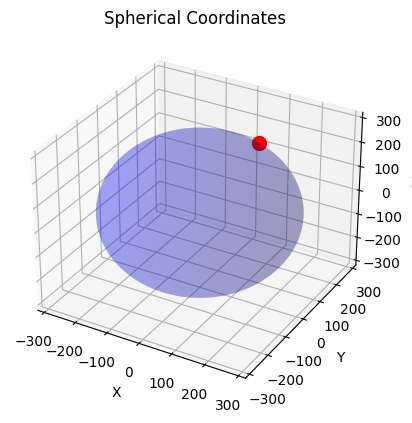

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Input spherical coordinates
r = float(input("Enter r (radial distance): "))
theta = float(input("Enter θ (theta) in degrees: "))
phi = float(input("Enter φ (phi) in degrees: "))

# Convert angles from degrees to radians
theta_rad = np.radians(theta)
phi_rad = np.radians(phi)

# Create a sphere to visualize the spherical angles
u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 100)
x = r * np.outer(np.cos(u), np.sin(v))
y = r * np.outer(np.sin(u), np.sin(v))
z = r * np.outer(np.ones(np.size(u)), np.cos(v))

# Convert spherical angles to Cartesian coordinates for visualization
x_point = r * np.sin(theta_rad) * np.cos(phi_rad)
y_point = r * np.sin(theta_rad) * np.sin(phi_rad)
z_point = r * np.cos(theta_rad)

# Create a 3D plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plot the sphere
ax.plot_surface(x, y, z, color='b', alpha=0.2)

# Plot the point representing the spherical angles
ax.scatter(x_point, y_point, z_point, color='r', s=100)

# Set labels and title
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Spherical Coordinates')

# Show plot
plt.show()




In [ ]:
import math

def cartesian_to_spherical(x, y, z):
    r = math.sqrt(x**2 + y**2 + z**2)
    theta = math.degrees(math.acos(z / r))
    phi = math.degrees(math.atan2(y, x))
    return r, theta, phi

x =58.7 # float(input("Enter X coordinate: "))
y =97.8 # float(input("Enter Y coordinate: "))
z =244 #float(input("Enter Z coordinate: "))

r, theta, phi = cartesian_to_spherical(x, y, z)

print("Spherical coordinates (r, θ, φ):")
print("r =", r)
print("θ (theta) =", theta)
print("φ (phi) =", phi)

Spherical coordinates (r, θ, φ):
r = 269.3446305386465
θ (theta) = 25.0548767747289
φ (phi) = 59.027628856727965


In [ ]:
import math

def spherical_to_cartesian(r, theta, phi):
    theta_rad = math.radians(theta)
    phi_rad = math.radians(phi)
    x = r * math.sin(theta_rad) * math.cos(phi_rad)
    y = r * math.sin(theta_rad) * math.sin(phi_rad)
    z = r * math.cos(theta_rad)
    return x, y, z

r = 270 # float(input("Enter r (radial distance): "))
theta = 25# float(input("Enter θ (theta) in degrees: "))
phi = 59 #float(input("Enter φ (phi) in degrees: "))

x, y, z = spherical_to_cartesian(r, theta, phi)

print("Cartesian coordinates (X, Y, Z):")
print("X =", x)
print("Y =", y)
print("Z =", z)

Cartesian coordinates (X, Y, Z):
X = 58.76941390616608
Y = 97.80872975379742
Z = 244.7031024998955


[[229.         426.         320.        ]
 [259.         426.         320.        ]
 [289.         426.         320.        ]
 ...
 [499.         151.35294118 680.        ]
 [513.11764706 151.35294118 680.        ]
 [527.23529412 151.35294118 680.        ]]
[[-37 -72]
 [-22 -72]
 [ -7 -72]
 ...
 [203 138]
 [218 138]
 [233 138]]


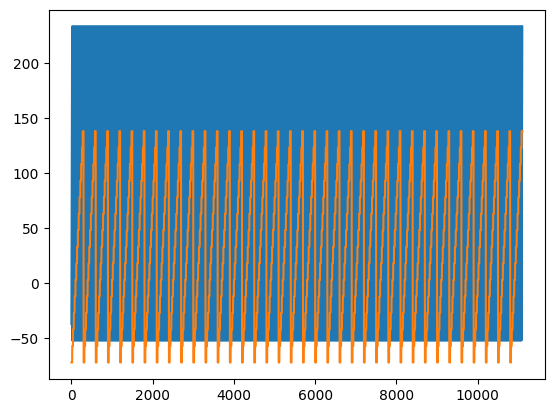

X: (11099, 3) Y: (11099, 2)
xtrain: (7769, 3) ytrian: (7769, 2)
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 300)               1200      
                                                                 
 dense_1 (Dense)             (None, 32)                9632      
                                                                 
 dense_2 (Dense)             (None, 16)                528       
                                                                 
 dense_3 (Dense)             (None, 2)                 34        
                                                                 
Total params: 11394 (44.51 KB)
Trainable params: 11394 (44.51 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/700
243/243 [==============================] - 4s 4ms/step - loss: 2307.9128
Epo

In [ ]:
#final network for 2d to 3d
from keras.models import Sequential
from keras.layers import Dense
from numpy import array
from numpy.random import uniform
from numpy import hstack
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import pandas as pd
from keras.models import model_from_json

#load dataset
df1 = pd.read_excel (r'/content/drive/MyDrive/calibration/data/final2D.xls')
X = df1.values
df2 = pd.read_excel (r'/content/drive/MyDrive/calibration/data/final3D.xls')
Y = df2.values

print(X)
print(Y)

plt.plot(Y)
plt.show()

print("X:", X.shape, "Y:", Y.shape)
in_dim = X.shape[1]
out_dim = Y.shape[1]

xtrain, xtest, ytrain, ytest=train_test_split(X, Y, test_size=0)
print("xtrain:", xtrain.shape, "ytrian:", ytrain.shape)

model = Sequential()
#model.add(Dense(300, input_dim=in_dim,  kernel_initializer='normal' , activation="relu"))
model.add(Dense(32,  kernel_initializer='normal' , activation="relu"))
model.add(Dense(16,  kernel_initializer='normal' , activation="relu"))
model.add(Dense(out_dim))
model.compile(loss="mse", optimizer="adam")
model.summary()

model.fit(xtrain, ytrain, epochs=700, batch_size=32, verbose=1)
 # serialize model to JSON
model_json = model.to_json()
with open("model.json", "w") as json_file:
    json_file.write(model_json)
# serialize weights to HDF5
model.save_weights("model.h5")
print("Saved model to disk")

df3 = pd.read_excel (r'/content/drive/MyDrive/lipmovement/outputpic/dfof3l1.xlsx')
xtest = df3.values
ypred = model.predict(xtest)

df4 = pd.DataFrame(ypred)
df4.to_excel('/content/drive/MyDrive/lipmovement/outputpic/xpredof3l1.xlsx', index=False)

df5 = pd.read_excel (r'/content/drive/MyDrive/lipmovement/outputpic/dfof3l2.xlsx')
xtest = df5.values
ypred = model.predict(xtest)

df6 = pd.DataFrame(ypred)
df6.to_excel('/content/drive/MyDrive/lipmovement/outputpic/xpredof3l2.xlsx', index=False)


[[ 106.67940521   94.42068806]
 [ 106.67940521   94.42068806]
 [ 107.08914948   93.07498318]
 [ 107.08914948   93.07498318]
 [ 106.99489594   92.50113545]
 [ 109.25640869   94.60880832]
 [ 109.25640869   94.60880832]
 [ 115.49945831  100.26778376]
 [ 115.21466827   98.38865425]
 [ 104.34270477  109.3300611 ]
 [ 115.18798065   98.06440772]
 [ 115.18798065   98.06440772]
 [ 104.34270477  100.2444917 ]
 [ 115.18798065  100.72642677]
 [ 103.78525543   95.7685132 ]
 [ 109.50722504  100.05445394]
 [ 110.0515976   100.05159756]
 [ 106.21122742   88.70191167]
 [  95.60362244   90.68942859]
 [ 103.78525543   94.21580865]
 [ 109.50722504  100.52600195]
 [ 110.0515976   100.52699838]
 [ 106.21122742   96.46480882]
 [  95.60362244  126.13464039]
 [  95.27223206  105.88377866]
 [  90.87461853  105.88377866]
 [  99.86617279  105.88377866]
 [  98.65583038  105.88377866]
 [ 119.6714859   105.40691217]
 [  99.86617279  105.40691217]
 [  98.65583038  105.40691217]
 [ 119.6714859   101.05702211]
 [ 898.4

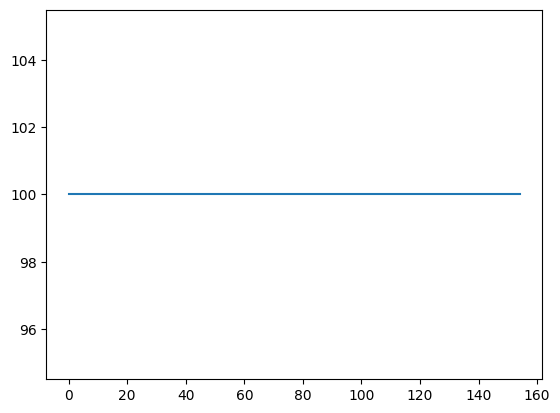

X: (155, 2) Y: (155, 1)
xtrain: (139, 2) ytrian: (139, 1)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 16)                  │              48 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 65 (260.00 B)

 Trainable params: 65 (260.00 B)

 Non-trainable params: 0 (0.00 B)

dict_keys(['loss', 'val_loss'])


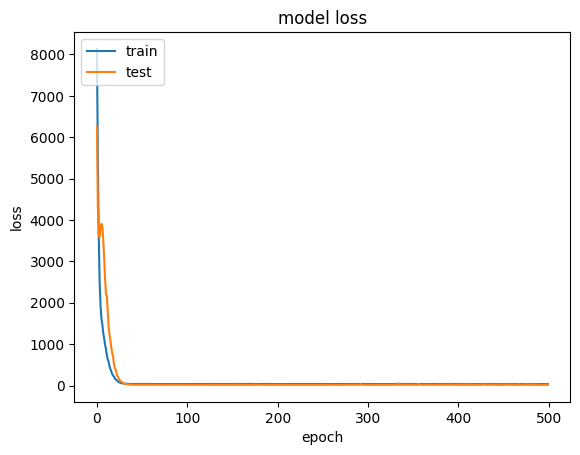

ValueError: The filename must end in `.weights.h5`. Received: filepath=model.h5

In [ ]:
#final network for audiovisual
from keras.models import Sequential
from keras.layers import Dense
from numpy import array
from numpy.random import uniform
from numpy import hstack
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import pandas as pd
from keras.models import model_from_json

#load dataset
df1 = pd.read_excel (r'/content/drive/MyDrive/lipmovement/ayinputtrain.xlsx')
X = df1.values
df2 = pd.read_excel (r'/content/drive/MyDrive/lipmovement/youtputtrain.xlsx')
Y = df2.values

print(X)
print(Y)

plt.plot(Y)
plt.show()

print("X:", X.shape, "Y:", Y.shape)
in_dim = X.shape[1]
out_dim = Y.shape[1]

xtrain, xtest, ytrain, ytest=train_test_split(X, Y, test_size=0.1)
print("xtrain:", xtrain.shape, "ytrian:", ytrain.shape)

model = Sequential()
#model.add(Dense(300, input_dim=in_dim,  kernel_initializer='normal' , activation="relu"))
model.add(Dense(16,  input_dim=in_dim, kernel_initializer='normal' ))
#model.add(Dense(16,  kernel_initializer='normal' ))
model.add(Dense(out_dim))
model.compile(loss="mse", optimizer="adam")
model.summary()

history= model.fit(xtrain, ytrain, validation_split=0.1, epochs=500, batch_size=8, verbose=0)

print(history.history.keys())


# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

 # serialize model to JSON
model_json = model.to_json()
with open("model.json", "w") as json_file:
    json_file.write(model_json)
# serialize weights to HDF5
model.save_weights("model.h5")
print("Saved model to disk")


#office1 s1 and s2 fix and move
df3 = pd.read_excel (r'/content/drive/MyDrive/lipmovement/outputpic/train/averagexpredof1l2.xlsx')
xtest = df3.values
ypred = model.predict(xtest)

df4 = pd.DataFrame(ypred)
df4.to_excel('/content/drive/MyDrive/lipmovement/outputpic/train/1layer/test.xlsx', index=False)

df5 = pd.read_excel (r'/content/drive/MyDrive/lipmovement/outputpic/train/yinputof1l2fix.xlsx')
xtest = df5.values
ypred = model.predict(xtest)

df6 = pd.DataFrame(ypred)
df6.to_excel('/content/drive/MyDrive/lipmovement/outputpic/train/1layer/yo1s2f.xlsx', index=False)

df7 = pd.read_excel (r'/content/drive/MyDrive/lipmovement/outputpic/train/yinputof1l2move.xlsx')
xtest = df7.values
ypred = model.predict(xtest)

df8 = pd.DataFrame(ypred)
df8.to_excel('/content/drive/MyDrive/lipmovement/outputpic/train/1layer/yo1s2m.xlsx', index=False)

#office3 s1 and s2 fix and move

df9 = pd.read_excel (r'/content/drive/MyDrive/lipmovement/outputpic/train/yinputof3l1fix.xlsx')
xtest = df9.values
ypred = model.predict(xtest)

df10 = pd.DataFrame(ypred)
df10.to_excel('/content/drive/MyDrive/lipmovement/outputpic/train/1layer/yo2s1f.xlsx', index=False)

df11 = pd.read_excel (r'/content/drive/MyDrive/lipmovement/outputpic/train/yinputof3l1move.xlsx')
xtest = df11.values
ypred = model.predict(xtest)

df12 = pd.DataFrame(ypred)
df12.to_excel('/content/drive/MyDrive/lipmovement/outputpic/train/1layer/yo2s1m.xlsx', index=False)




Lengths of arrays before truncation: {'Method1': 153, 'Method2': 141, 'RealData': 182}
Minimum length: 141
Lengths of arrays after truncation: {'Method1': 141, 'Method2': 141, 'RealData': 141}
Mean Squared Error for Method 1: 34.533146733967364
Mean Squared Error for Method 2: 48.910727283599186
Mean Absolute Error for Method 1: 3.7576727313475176
Mean Absolute Error for Method 2: 5.799463463475178


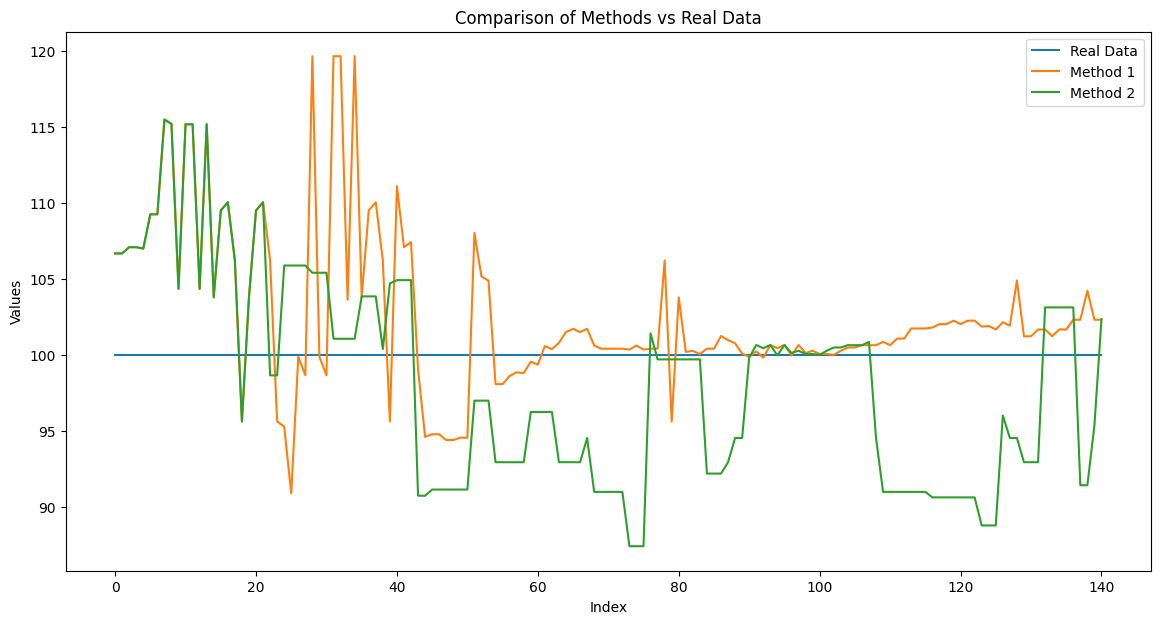

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

# Data preparation
data = {
    'Method1': [
        106.6794052, 106.6794052, 107.0891495, 107.0891495, 106.9948959, 109.2564087,
        109.2564087, 115.4994583, 115.2146683, 104.3427048, 115.1879807, 115.1879807,
        104.3427048, 115.1879807, 103.7852554, 109.507225, 110.0515976, 106.2112274,
        95.60362244, 103.7852554, 109.507225, 110.0515976, 106.2112274, 95.60362244,
        95.27223206, 90.87461853, 99.86617279, 98.65583038, 119.6714859, 99.86617279,
        98.65583038, 119.6714859, 119.6714859, 103.625854, 119.6714859, 103.7852554,
        109.507225, 110.0515976, 106.2112274, 95.60362244, 111.1030884, 107.0919342,
        107.4239426, 99.02733612, 94.59638214, 94.76805115, 94.76805115, 94.38559723,
        94.38559723, 94.5429306, 94.5429306, 108.0260391, 105.158226, 104.8834, 98.0697403,
        98.0697403, 98.60796356, 98.85138702, 98.79524231, 99.54672241, 99.35306549,
        100.572319, 100.3734818, 100.7891998, 101.5020828, 101.7133408, 101.5020752,
        101.7133408, 100.6131973, 100.4033737, 100.4033737, 100.4033737, 100.4033737,
        100.3443985, 100.6131973, 100.3443985, 100.4033737, 100.4033737, 106.2112274,
        95.60362244, 103.7852554, 100.1949692, 100.2539291, 100.0469437, 100.4033737,
        100.4033737, 101.239418, 100.9691849, 100.7593613, 100.077034, 99.87047577,
        100.2264709, 99.81150818, 100.6475601, 100.4363022, 100.6475601, 99.96237946,
        100.6475601, 100.1155319, 100.2680893, 100.0560379, 100.0560379, 99.99373627,
        100.2680893, 100.4815903, 100.4815903, 100.6349411, 100.6349411, 100.6349411,
        100.8517227, 100.6349411, 101.0700378, 101.0700378, 101.734169, 101.734169,
        101.734169, 101.7975388, 102.0226212, 102.0226212, 102.2493057, 102.0226212,
        102.2493057, 102.2493057, 101.8594742, 101.8959122, 101.6691208, 102.1431122,
        101.9179001, 104.8969421, 101.2202682, 101.2202759, 101.6691132, 101.6691208,
        101.2202682, 101.6691208, 101.6691208, 102.3114853, 102.3114853, 104.2225494,
        102.3114853, 102.3114853, 102.2493057, 102.663208, 102.3114853, 102.663208,
        102.2493057, 102.4365158, 102.0226212, 102.2493057, 101.8594742, 101.8594742,
        102.354393, 102.3114853
    ],
    'Method2': [
        106.6794052, 106.6794052, 107.0891495, 107.0891495, 106.9948959, 109.2564087,
        109.2564087, 115.4994583, 115.2146683, 104.3427048, 115.1879807, 115.1879807,
        104.3427048, 115.1879807, 103.7852554, 109.507225, 110.0515976, 106.2112274,
        95.60362244, 103.7852554, 109.507225, 110.0515976, 98.64531513, 98.64531513,
        105.8837787, 105.8837787, 105.8837787, 105.8837787, 105.4069122, 105.4069122,
        105.4069122, 101.0570221, 101.0570221, 101.0570221, 101.0570221, 103.8485114,
        103.8485114, 103.8485114, 100.3825159, 104.7033726, 104.9194789, 104.9194789,
        104.9194789, 90.71740358, 90.71740358, 91.12387644, 91.12387644, 91.12387644,
        91.12387644, 91.12387644, 91.12387644, 96.9804857, 96.9804857, 96.9804857,
        92.92467721, 92.92467721, 92.92467721, 92.92467721, 92.92467721, 96.23562352,
        96.23562352, 96.23562352, 96.23562352, 92.92611692, 92.92611692, 92.92611692,
        92.92611692, 94.52193794, 90.96988752, 90.96988752, 90.96988752, 90.96988752,
        90.96988752, 87.3901268, 87.3901268, 87.3901268, 101.410513, 99.69839169,
        99.69839169, 99.69839169, 99.69839169, 99.69839169, 99.69839169, 99.69839169,
        92.17600994, 92.17600994, 92.17600994, 92.92611692, 94.52193794, 94.52193794,
        99.81150818, 100.6475601, 100.4363022, 100.6475601, 99.96237946, 100.6475601,
        100.1155319, 100.2680893, 100.0560379, 100.0560379, 99.99373627, 100.2680893,
        100.4815903, 100.4815903, 100.6349411, 100.6349411, 100.6349411, 100.8517227,
        94.52193794, 90.96988752, 90.96988752, 90.96988752, 90.96988752, 90.96988752,
        90.96988752, 90.96988752, 90.60725854, 90.60725854, 90.60725854, 90.60725854,
        90.60725854, 90.60725854, 90.60725854, 88.7590695, 88.7590695, 88.7590695,
        96.00259854, 94.52193794, 94.52193794, 92.92611692, 92.92611692, 92.92611692,
        103.1240059, 103.1240059, 103.1240059, 103.1240059, 103.1240059, 91.40857378,
        91.40857378, 95.34315684, 102.354393
    ],
    'RealData': [
        100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100,
        100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100,
        100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100,
        100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100,
        100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100,
        100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100,
        100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100,
        100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100,
        100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100,
        100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100,
        100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100,
        100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100,
        100, 100
    ]
}

# Check the lengths of each array
lengths = {k: len(v) for k, v in data.items()}
print("Lengths of arrays before truncation:", lengths)

# Ensure all columns have the same length
min_length = min(lengths.values())
print("Minimum length:", min_length)

# Truncate each array to the minimum length
data = {k: v[:min_length] for k, v in data.items()}

# Check the lengths again
lengths_after_truncation = {k: len(v) for k, v in data.items()}
print("Lengths of arrays after truncation:", lengths_after_truncation)

# Create DataFrame
df = pd.DataFrame(data)

# Calculate errors
mse1 = mean_squared_error(df['RealData'], df['Method1'])
mse2 = mean_squared_error(df['RealData'], df['Method2'])
mae1 = mean_absolute_error(df['RealData'], df['Method1'])
mae2 = mean_absolute_error(df['RealData'], df['Method2'])

print("Mean Squared Error for Method 1:", mse1)
print("Mean Squared Error for Method 2:", mse2)
print("Mean Absolute Error for Method 1:", mae1)
print("Mean Absolute Error for Method 2:", mae2)

# Visualize the errors
plt.figure(figsize=(14, 7))
plt.plot(df['RealData'], label='Real Data')
plt.plot(df['Method1'], label='Method 1')
plt.plot(df['Method2'], label='Method 2')
plt.legend()
plt.xlabel('Index')
plt.ylabel('Values')
plt.title('Comparison of Methods vs Real Data')
plt.show()


Mean Squared Error for Method 1: 34.533146733967364
Mean Squared Error for Method 2: 48.910727283599186
Mean Absolute Error for Method 1: 3.7576727313475176
Mean Absolute Error for Method 2: 5.799463463475178
Mean Squared Error for Simple Average: 28.650829071994178
Mean Absolute Error for Simple Average: 4.090514969609928
Mean Squared Error for Weighted Average: 27.800239811441635
Mean Absolute Error for Weighted Average: 3.860816574937731


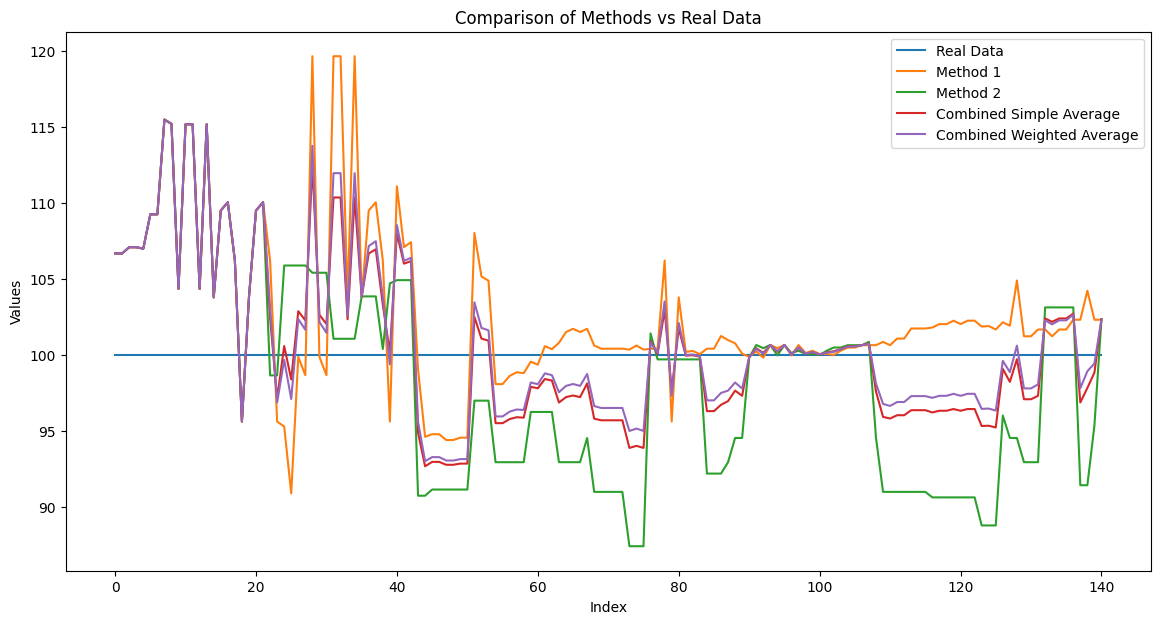

In [ ]:
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt


df = pd.DataFrame(data)

# Calculate Mean Squared Error and Mean Absolute Error for both methods
mse1 = mean_squared_error(df['RealData'], df['Method1'])
mse2 = mean_squared_error(df['RealData'], df['Method2'])

mae1 = mean_absolute_error(df['RealData'], df['Method1'])
mae2 = mean_absolute_error(df['RealData'], df['Method2'])

print("Mean Squared Error for Method 1:", mse1)
print("Mean Squared Error for Method 2:", mse2)
print("Mean Absolute Error for Method 1:", mae1)
print("Mean Absolute Error for Method 2:", mae2)

# Simple Averaging
df['Combined_Simple_Average'] = (df['Method1'] + df['Method2']) / 2

# Calculate errors for simple averaging
mse_simple_avg = mean_squared_error(df['RealData'], df['Combined_Simple_Average'])
mae_simple_avg = mean_absolute_error(df['RealData'], df['Combined_Simple_Average'])

print("Mean Squared Error for Simple Average:", mse_simple_avg)
print("Mean Absolute Error for Simple Average:", mae_simple_avg)

# Weighted Averaging
weight_method1 = 1 / mse1
weight_method2 = 1 / mse2
total_weight = weight_method1 + weight_method2

df['Combined_Weighted_Average'] = (df['Method1'] * weight_method1 + df['Method2'] * weight_method2) / total_weight

# Calculate errors for weighted averaging
mse_weighted_avg = mean_squared_error(df['RealData'], df['Combined_Weighted_Average'])
mae_weighted_avg = mean_absolute_error(df['RealData'], df['Combined_Weighted_Average'])

print("Mean Squared Error for Weighted Average:", mse_weighted_avg)
print("Mean Absolute Error for Weighted Average:", mae_weighted_avg)

# Visualize the errors
plt.figure(figsize=(14, 7))
plt.plot(df['RealData'], label='Real Data')
plt.plot(df['Method1'], label='Method 1')
plt.plot(df['Method2'], label='Method 2')
plt.plot(df['Combined_Simple_Average'], label='Combined Simple Average')
plt.plot(df['Combined_Weighted_Average'], label='Combined Weighted Average')
plt.legend()
plt.xlabel('Index')
plt.ylabel('Values')
plt.title('Comparison of Methods vs Real Data')
plt.show()


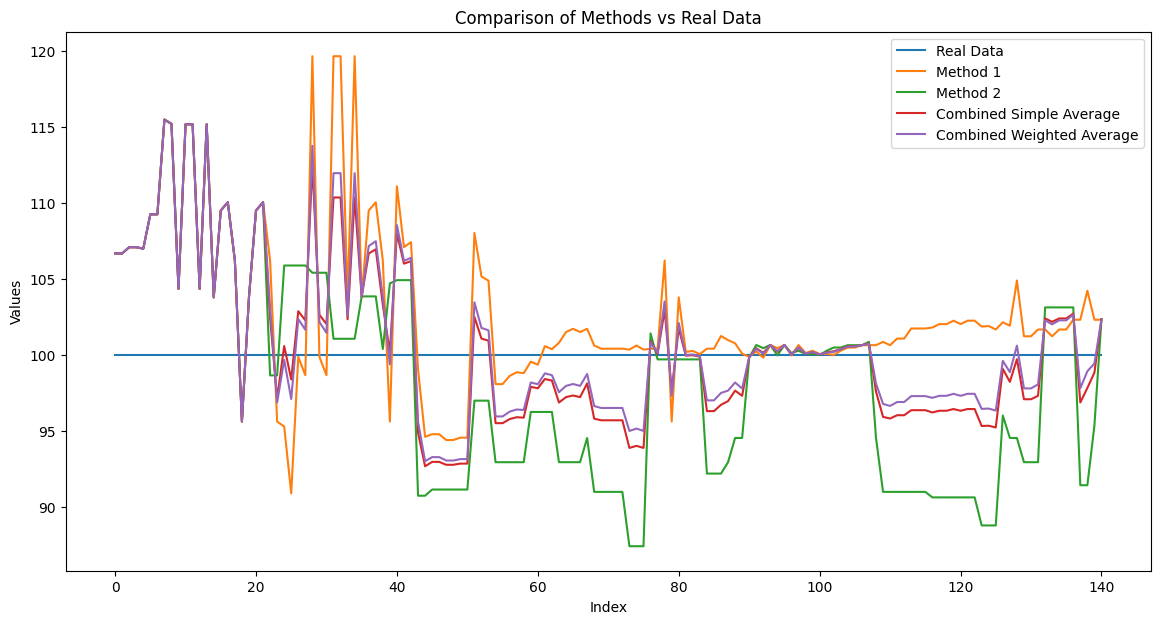

In [ ]:
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

df = pd.DataFrame(data)

# Calculate Mean Squared Error and Mean Absolute Error for both methods
mse1 = mean_squared_error(df['RealData'], df['Method1'])
mse2 = mean_squared_error(df['RealData'], df['Method2'])

mae1 = mean_absolute_error(df['RealData'], df['Method1'])
mae2 = mean_absolute_error(df['RealData'], df['Method2'])

# Simple Averaging
df['Combined_Simple_Average'] = (df['Method1'] + df['Method2']) / 2

# Calculate errors for simple averaging
mse_simple_avg = mean_squared_error(df['RealData'], df['Combined_Simple_Average'])
mae_simple_avg = mean_absolute_error(df['RealData'], df['Combined_Simple_Average'])

# Weighted Averaging
weight_method1 = 1 / mse1
weight_method2 = 1 / mse2
total_weight = weight_method1 + weight_method2

df['Combined_Weighted_Average'] = (df['Method1'] * weight_method1 + df['Method2'] * weight_method2) / total_weight

# Calculate errors for weighted averaging
mse_weighted_avg = mean_squared_error(df['RealData'], df['Combined_Weighted_Average'])
mae_weighted_avg = mean_absolute_error(df['RealData'], df['Combined_Weighted_Average'])

# Save combined data from each method along with real data to an Excel file
combined_data_df = pd.DataFrame({
    'RealData': df['RealData'],
    'Method1': df['Method1'],
    'Method2': df['Method2'],
    'Combined_Simple_Average': df['Combined_Simple_Average'],
    'Combined_Weighted_Average': df['Combined_Weighted_Average']
})

combined_data_df.to_excel('combined_method_data.xlsx', index=False)

# Visualize the errors
plt.figure(figsize=(14, 7))
plt.plot(df['RealData'], label='Real Data')
plt.plot(df['Method1'], label='Method 1')
plt.plot(df['Method2'], label='Method 2')
plt.plot(df['Combined_Simple_Average'], label='Combined Simple Average')
plt.plot(df['Combined_Weighted_Average'], label='Combined Weighted Average')
plt.legend()
plt.xlabel('Index')
plt.ylabel('Values')
plt.title('Comparison of Methods vs Real Data')
plt.show()


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Read data from Excel file
file_path = '/content/drive/MyDrive/lipmovement/inputof1l1fix.xlsx'  # Replace with your actual file path
df = pd.read_excel(file_path)

# Strip leading/trailing whitespace characters from column names
df.columns = df.columns.str.strip()

# Check the lengths of each array
lengths = {col: df[col].size for col in df.columns}
print("Lengths of arrays before truncation:", lengths)

# Ensure all columns have the same length
min_length = min(lengths.values())
print("Minimum length:", min_length)

# Truncate each column to the minimum length
df = df.iloc[:min_length]

# Check the lengths again
lengths_after_truncation = {col: df[col].size for col in df.columns}
print("Lengths of arrays after truncation:", lengths_after_truncation)

# Calculate Mean Squared Error and Mean Absolute Error for both methods
mse1 = mean_squared_error(df['RealData'], df['Method1'])
mse2 = mean_squared_error(df['RealData'], df['Method2'])

mae1 = mean_absolute_error(df['RealData'], df['Method1'])
mae2 = mean_absolute_error(df['RealData'], df['Method2'])

# Simple Averaging
df['Combined_Simple_Average'] = (df['Method1'] + df['Method2']) / 2

# Calculate errors for simple averaging
mse_simple_avg = mean_squared_error(df['RealData'], df['Combined_Simple_Average'])
mae_simple_avg = mean_absolute_error(df['RealData'], df['Combined_Simple_Average'])

# Weighted Averaging
weight_method1 = 1 / mse1
weight_method2 = 1 / mse2
total_weight = weight_method1 + weight_method2

df['Combined_Weighted_Average'] = (df['Method1'] * weight_method1 + df['Method2'] * weight_method2) / total_weight

# Calculate errors for weighted averaging
mse_weighted_avg = mean_squared_error(df['RealData'], df['Combined_Weighted_Average'])
mae_weighted_avg = mean_absolute_error(df['RealData'], df['Combined_Weighted_Average'])

# Define features and target
X = df[['Method1', 'Method2']].values
y = df['RealData'].values

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the neural network model
model = Sequential([
    Dense(10, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(5, activation='relu'),
    Dense(1)  # Output layer
])

model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
model.fit(X_train, y_train, epochs=100, batch_size=10, verbose=1, validation_split=0.2)

# Make predictions
train_predictions = model.predict(X_train).flatten()
test_predictions = model.predict(X_test).flatten()

# Evaluate the model
train_mse = mean_squared_error(y_train, train_predictions)
test_mse = mean_squared_error(y_test, test_predictions)
train_mae = mean_absolute_error(y_train, train_predictions)
test_mae = mean_absolute_error(y_test, test_predictions)

print("Train Mean Squared Error:", train_mse)
print("Test Mean Squared Error:", test_mse)
print("Train Mean Absolute Error:", train_mae)
print("Test Mean Absolute Error:", test_mae)

# Add predictions to the DataFrame
df['Combined_Neural_Network'] = model.predict(X).flatten()

# Save combined data from each method along with real data to an Excel file
combined_data_df = pd.DataFrame({
    'RealData': df['RealData'],
    'Method1': df['Method1'],
    'Method2': df['Method2'],
    'Combined_Simple_Average': df['Combined_Simple_Average'],
    'Combined_Weighted_Average': df['Combined_Weighted_Average'],
    'Combined_Neural_Network': df['Combined_Neural_Network']
})

combined_data_df.to_excel('combined_method_data_with_nn.xlsx', index=False)

# Save combined error from each method along with real data to an Excel file
combined_error_df = pd.DataFrame({
    'mse_simple_avg': [mse_simple_avg],
    'mae_simple_avg': [mae_simple_avg],
    'mse_weighted_avg': [mse_weighted_avg],
    'mae_weighted_avg': [mae_weighted_avg],
})

combined_error_df.to_excel('error_method_data_with_nn.xlsx', index=False)

# Visualize the errors
plt.figure(figsize=(14, 7))
plt.plot(df['RealData'], label='Real Data')
plt.plot(df['Method1'], label='Method 1')
plt.plot(df['Method2'], label='Method 2')
plt.plot(df['Combined_Simple_Average'], label='Combined Simple Average')
plt.plot(df['Combined_Weighted_Average'], label='Combined Weighted Average')
plt.plot(df['Combined_Neural_Network'], label='Combined Neural Network')
plt.legend()
plt.xlabel('Index')
plt.ylabel('Values')
plt.title('Comparison of Methods vs Real Data')
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/lipmovement/inputof1l1fix.xlsx'

In [ ]:
# Save combined error from each method along with real data to an Excel file
combined_error_df = pd.DataFrame({
    'mse_simple_avg': [mse_simple_avg],
    'mae_simple_avg': [mae_simple_avg],
    'mse_weighted_avg': [mse_weighted_avg],
    'mae_weighted_avg': [mae_weighted_avg],
})

combined_data_df.to_excel('error_method_data_with_nn.xlsx', index=False)

print(mse_simple_avg)
print(mae_simple_avg)
print(mse_weighted_avg)
print(mae_weighted_avg)

28.650829071994178
4.090514969609928
27.800239811441635
3.860816574937731


Lengths of arrays before truncation: {'VXpred': 152, 'AXpred': 152, 'Averagexpred': 152, 'Xreal': 152}
Minimum length: 152
Lengths of arrays after truncation: {'VXpred': 152, 'AXpred': 152, 'Averagexpred': 152, 'Xreal': 152}
Epoch 1/100
11/11 [==============================] - 1s 25ms/step - loss: 1179.5884 - val_loss: 917.1123
Epoch 2/100
11/11 [==============================] - 0s 6ms/step - loss: 925.2010 - val_loss: 723.3236
Epoch 3/100
11/11 [==============================] - 0s 6ms/step - loss: 716.1645 - val_loss: 551.0584
Epoch 4/100
11/11 [==============================] - 0s 6ms/step - loss: 530.4337 - val_loss: 401.1686
Epoch 5/100
11/11 [==============================] - 0s 8ms/step - loss: 369.3076 - val_loss: 279.3607
Epoch 6/100
11/11 [==============================] - 0s 7ms/step - loss: 244.7720 - val_loss: 180.7120
Epoch 7/100
11/11 [==============================] - 0s 6ms/step - loss: 151.9607 - val_loss: 116.9325
Epoch 8/100
11/11 [==============================] -

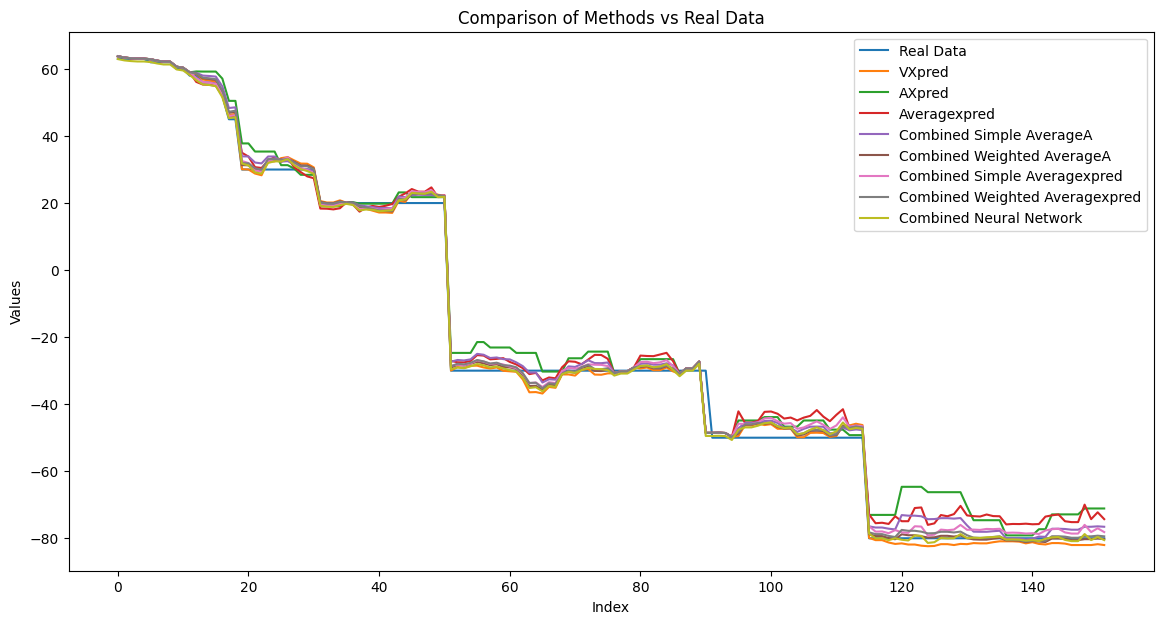

In [ ]:
# Train network for X
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Read data from Excel file
file_path = '/content/drive/MyDrive/lipmovement/AVdata/xinputof2l1move.xlsx'  # Replace with your actual file path
df = pd.read_excel(file_path)

# Strip leading/trailing whitespace characters from column names
df.columns = df.columns.str.strip()

# Check the lengths of each array
lengths = {col: df[col].size for col in df.columns}
print("Lengths of arrays before truncation:", lengths)

# Ensure all columns have the same length
min_length = min(lengths.values())
print("Minimum length:", min_length)

# Truncate each column to the minimum length
df = df.iloc[:min_length]

# Check the lengths again
lengths_after_truncation = {col: df[col].size for col in df.columns}
print("Lengths of arrays after truncation:", lengths_after_truncation)

# Calculate Mean Squared Error and Mean Absolute Error for both methods
mse1 = mean_squared_error(df['Xreal'], df['VXpred'])
mse2 = mean_squared_error(df['Xreal'], df['AXpred'])
mse3 = mean_squared_error(df['Xreal'], df['Averagexpred'])

mae1 = mean_absolute_error(df['Xreal'], df['VXpred'])
mae2 = mean_absolute_error(df['Xreal'], df['AXpred'])
mae2 = mean_absolute_error(df['Xreal'], df['Averagexpred'])

# Simple Averaging
df['Combined_Simple_AverageA'] = (df['VXpred'] + df['AXpred']) / 2
df['Combined_Simple_Averagexpred'] = (df['VXpred'] + df['Averagexpred']) / 2

# Calculate errors for simple averaging
mse_simple_avgA = mean_squared_error(df['Xreal'], df['Combined_Simple_AverageA'])
mse_simple_avgAV = mean_squared_error(df['Xreal'], df['Combined_Simple_Averagexpred'])
mae_simple_avgA = mean_absolute_error(df['Xreal'], df['Combined_Simple_AverageA'])
mae_simple_avgAV = mean_absolute_error(df['Xreal'], df['Combined_Simple_Averagexpred'])

# Weighted Averaging
weight_VXpred = 1 / mse1
weight_AXpred = 1 / mse2
weight_Averagexpred = 1 / mse3
total_weightA = weight_VXpred + weight_AXpred
total_weightAV = weight_VXpred + weight_Averagexpred

df['Combined_Weighted_AverageA'] = (df['VXpred'] * weight_VXpred + df['AXpred'] * weight_AXpred) / total_weightA
df['Combined_Weighted_Averagexpred'] = (df['VXpred'] * weight_VXpred + df['AXpred'] * weight_Averagexpred) / total_weightAV

# Calculate errors for weighted averaging
mse_weighted_avgA = mean_squared_error(df['Xreal'], df['Combined_Weighted_AverageA'])
mae_weighted_avgAV = mean_absolute_error(df['Xreal'], df['Combined_Weighted_Averagexpred'])

# Define features and target
X = df[['VXpred', 'Averagexpred']].values
y = df['Xreal'].values

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=153)

# Define the neural network model
model = Sequential([
    Dense(10, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(5, activation='relu'),
    Dense(1)  # Output layer
])

model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
model.fit(X_train, y_train, epochs=100, batch_size=10, verbose=1, validation_split=0.2)

# Make predictions
train_predictions = model.predict(X_train).flatten()
test_predictions = model.predict(X_test).flatten()

# Evaluate the model
train_mse = mean_squared_error(y_train, train_predictions)
test_mse = mean_squared_error(y_test, test_predictions)
train_mae = mean_absolute_error(y_train, train_predictions)
test_mae = mean_absolute_error(y_test, test_predictions)

print("Train Mean Squared Error:", train_mse)
print("Test Mean Squared Error:", test_mse)
print("Train Mean Absolute Error:", train_mae)
print("Test Mean Absolute Error:", test_mae)

# Add predictions to the DataFrame
df['Combined_Neural_Network'] = model.predict(X).flatten()

# Save combined data from each method along with real data to an Excel file
combined_data_df = pd.DataFrame({
    'Xreal': df['Xreal'],
    'VXpred': df['VXpred'],
    'AXpred': df['AXpred'],
    'Averagexpred': df['Averagexpred'],
    'Combined_Simple_AverageA': df['Combined_Simple_AverageA'],
    'Combined_Weighted_AverageA': df['Combined_Weighted_AverageA'],
    'Combined_Simple_Averagexpred': df['Combined_Simple_Averagexpred'],
    'Combined_Weighted_Averagexpred': df['Combined_Weighted_Averagexpred'],
    'Combined_Neural_Network': df['Combined_Neural_Network'],
})

combined_data_df.to_excel('combined_of2l1move.xlsx', index=False)

# Save combined error from each method along with real data to an Excel file
combined_error_df = pd.DataFrame({
    'mse_simple_avg': [mse_simple_avgA],
    'mae_simple_avg': [mae_simple_avgAV],
    'mse_weighted_avg': [mse_weighted_avgA],
    'mae_weighted_avg': [mae_weighted_avgAV],
})

combined_error_df.to_excel('error_method_data_with_nn.xlsx', index=False)

# Visualize the errors
plt.figure(figsize=(14, 7))
plt.plot(df['Xreal'], label='Real Data')
plt.plot(df['VXpred'], label='VXpred')
plt.plot(df['AXpred'], label='AXpred')
plt.plot(df['Averagexpred'], label='Averagexpred')
plt.plot(df['Combined_Simple_AverageA'], label='Combined Simple AverageA')
plt.plot(df['Combined_Weighted_AverageA'], label='Combined Weighted AverageA')
plt.plot(df['Combined_Simple_Averagexpred'], label='Combined Simple Averagexpred')
plt.plot(df['Combined_Weighted_Averagexpred'], label='Combined Weighted Averagexpred')
plt.plot(df['Combined_Neural_Network'], label='Combined Neural Network')
plt.legend()
plt.xlabel('Index')
plt.ylabel('Values')
plt.title('Comparison of Methods vs Real Data')
plt.show()


Lengths of arrays before truncation: {'VXpred': 151, 'AXpred': 151, 'Averagexpred': 151, 'Xreal': 151}
Minimum length: 151
Lengths of arrays after truncation: {'VXpred': 151, 'AXpred': 151, 'Averagexpred': 151, 'Xreal': 151}
1/1 [==============================] - 0s 149ms/step
Train Mean Squared Error: 7.870274081979922
Test Mean Squared Error: 8.616086339171488
Train Mean Absolute Error: 2.586518916377315
Test Mean Absolute Error: 2.5597221851348877
5/5 [==============================] - 0s 9ms/step


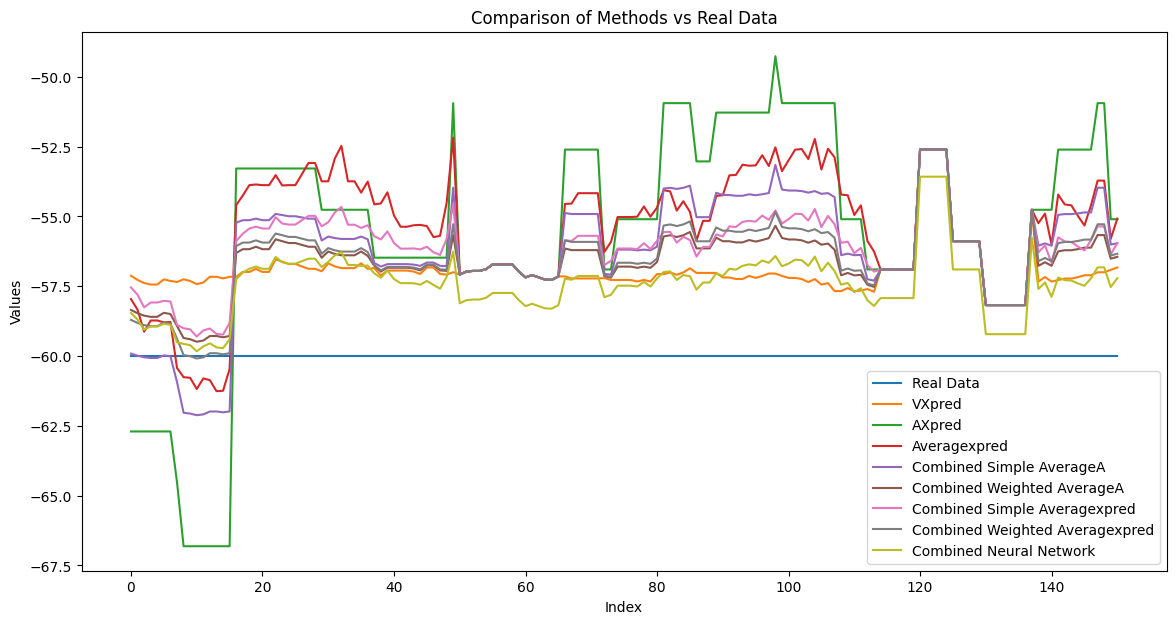

In [ ]:
#final trained network and other methods for combine Audio and Visual : Just for X
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Read data from Excel file
file_path = '/content/drive/MyDrive/lipmovement/AVdata/xinputof1l2fix.xlsx'  # Replace with your actual file path
df = pd.read_excel(file_path)

# Strip leading/trailing whitespace characters from column names
df.columns = df.columns.str.strip()

# Check the lengths of each array
lengths = {col: df[col].size for col in df.columns}
print("Lengths of arrays before truncation:", lengths)

# Ensure all columns have the same length
min_length = min(lengths.values())
print("Minimum length:", min_length)

# Truncate each column to the minimum length
df = df.iloc[:min_length]

# Check the lengths again
lengths_after_truncation = {col: df[col].size for col in df.columns}
print("Lengths of arrays after truncation:", lengths_after_truncation)

# Calculate Mean Squared Error and Mean Absolute Error for both methods
mse1 = mean_squared_error(df['Xreal'], df['VXpred'])
mse2 = mean_squared_error(df['Xreal'], df['AXpred'])
mse3 = mean_squared_error(df['Xreal'], df['Averagexpred'])

mae1 = mean_absolute_error(df['Xreal'], df['VXpred'])
mae2 = mean_absolute_error(df['Xreal'], df['AXpred'])
mae2 = mean_absolute_error(df['Xreal'], df['Averagexpred'])

# Simple Averaging
df['Combined_Simple_AverageA'] = (df['VXpred'] + df['AXpred']) / 2
df['Combined_Simple_Averagexpred'] = (df['VXpred'] + df['Averagexpred']) / 2

# Calculate errors for simple averaging
mse_simple_avgA = mean_squared_error(df['Xreal'], df['Combined_Simple_AverageA'])
mse_simple_avgAV = mean_squared_error(df['Xreal'], df['Combined_Simple_Averagexpred'])
mae_simple_avgA = mean_absolute_error(df['Xreal'], df['Combined_Simple_AverageA'])
mae_simple_avgAV = mean_absolute_error(df['Xreal'], df['Combined_Simple_Averagexpred'])

# Weighted Averaging
weight_VXpred = 1 / mse1
weight_AXpred = 1 / mse2
weight_Averagexpred = 1 / mse3
total_weightA = weight_VXpred + weight_AXpred
total_weightAV = weight_VXpred + weight_Averagexpred

df['Combined_Weighted_AverageA'] = (df['VXpred'] * weight_VXpred + df['AXpred'] * weight_AXpred) / total_weightA
df['Combined_Weighted_Averagexpred'] = (df['VXpred'] * weight_VXpred + df['AXpred'] * weight_Averagexpred) / total_weightAV

# Calculate errors for weighted averaging
mse_weighted_avgA = mean_squared_error(df['Xreal'], df['Combined_Weighted_AverageA'])
mae_weighted_avgAV = mean_absolute_error(df['Xreal'], df['Combined_Weighted_Averagexpred'])

# Define features and target
X = df[['VXpred', 'Averagexpred']].values
y = df['Xreal'].values

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=100)



# Make predictions
train_predictions = model.predict(X_train).flatten()
test_predictions = model.predict(X_test).flatten()

# Evaluate the model
train_mse = mean_squared_error(y_train, train_predictions)
test_mse = mean_squared_error(y_test, test_predictions)
train_mae = mean_absolute_error(y_train, train_predictions)
test_mae = mean_absolute_error(y_test, test_predictions)

print("Train Mean Squared Error:", train_mse)
print("Test Mean Squared Error:", test_mse)
print("Train Mean Absolute Error:", train_mae)
print("Test Mean Absolute Error:", test_mae)

# Add predictions to the DataFrame
df['Combined_Neural_Network'] = model.predict(X).flatten()

# Save combined data from each method along with real data to an Excel file
combined_data_df = pd.DataFrame({
    'Xreal': df['Xreal'],
    'VXpred': df['VXpred'],
    'AXpred': df['AXpred'],
    'Averagexpred': df['Averagexpred'],
    'Combined_Simple_AverageA': df['Combined_Simple_AverageA'],
    'Combined_Weighted_AverageA': df['Combined_Weighted_AverageA'],
    'Combined_Simple_Averagexpred': df['Combined_Simple_Averagexpred'],
    'Combined_Weighted_Averagexpred': df['Combined_Weighted_Averagexpred'],
    'Combined_Neural_Network': df['Combined_Neural_Network'],
})

combined_data_df.to_excel('combined_xinputof1l2fix.xlsx', index=False)

# Save combined error from each method along with real data to an Excel file
combined_error_df = pd.DataFrame({
    'mse_simple_avg': [mse_simple_avgA],
    'mae_simple_avg': [mae_simple_avgAV],
    'mse_weighted_avg': [mse_weighted_avgA],
    'mae_weighted_avg': [mae_weighted_avgAV],
})

combined_error_df.to_excel('error_method_data_with_nn.xlsx', index=False)

# Visualize the errors
plt.figure(figsize=(14, 7))
plt.plot(df['Xreal'], label='Real Data')
plt.plot(df['VXpred'], label='VXpred')
plt.plot(df['AXpred'], label='AXpred')
plt.plot(df['Averagexpred'], label='Averagexpred')
plt.plot(df['Combined_Simple_AverageA'], label='Combined Simple AverageA')
plt.plot(df['Combined_Weighted_AverageA'], label='Combined Weighted AverageA')
plt.plot(df['Combined_Simple_Averagexpred'], label='Combined Simple Averagexpred')
plt.plot(df['Combined_Weighted_Averagexpred'], label='Combined Weighted Averagexpred')
plt.plot(df['Combined_Neural_Network'], label='Combined Neural Network')
plt.legend()
plt.xlabel('Index')
plt.ylabel('Values')
plt.title('Comparison of Methods vs Real Data')
plt.show()


Lengths of arrays before truncation: {'VYpred': 155, 'AYpred': 155, 'Averageypred': 155, 'Yreal': 155}
Minimum length: 155
Lengths of arrays after truncation: {'VYpred': 155, 'AYpred': 155, 'Averageypred': 155, 'Yreal': 155}
Epoch 1/100
12/12 [==============================] - 3s 20ms/step - loss: 21144.2832 - val_loss: 21209.3125
Epoch 2/100
12/12 [==============================] - 0s 5ms/step - loss: 19503.9844 - val_loss: 19394.2324
Epoch 3/100
12/12 [==============================] - 0s 5ms/step - loss: 17971.7305 - val_loss: 17842.0625
Epoch 4/100
12/12 [==============================] - 0s 7ms/step - loss: 16585.1973 - val_loss: 16379.3799
Epoch 5/100
12/12 [==============================] - 0s 5ms/step - loss: 15272.6055 - val_loss: 15012.0293
Epoch 6/100
12/12 [==============================] - 0s 6ms/step - loss: 14014.1123 - val_loss: 13790.8965
Epoch 7/100
12/12 [==============================] - 0s 7ms/step - loss: 12962.6572 - val_loss: 12618.4082
Epoch 8/100
12/12 [======

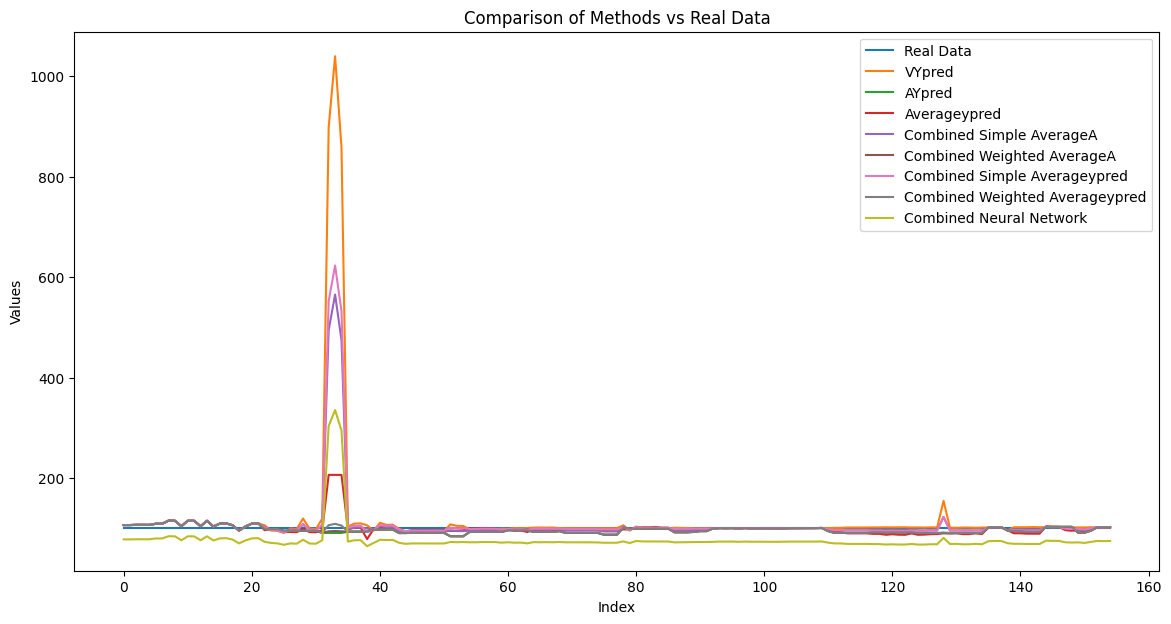

In [ ]:
#Train network for Y
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Read data from Excel file
file_path = '/content/drive/MyDrive/lipmovement/AVdata/yinputof1l1move.xlsx'  # Replace with your actual file path
df = pd.read_excel(file_path)

# Strip leading/trailing whitespace characters from column names
df.columns = df.columns.str.strip()

# Check the lengths of each array
lengths = {col: df[col].size for col in df.columns}
print("Lengths of arrays before truncation:", lengths)

# Ensure all columns have the same length
min_length = min(lengths.values())
print("Minimum length:", min_length)

# Truncate each column to the minimum length
df = df.iloc[:min_length]

# Check the lengths again
lengths_after_truncation = {col: df[col].size for col in df.columns}
print("Lengths of arrays after truncation:", lengths_after_truncation)

# Calculate Mean Squared Error and Mean Absolute Error for both methods
mse1 = mean_squared_error(df['Yreal'], df['VYpred'])
mse2 = mean_squared_error(df['Yreal'], df['AYpred'])
mse3 = mean_squared_error(df['Yreal'], df['Averageypred'])

mae1 = mean_absolute_error(df['Yreal'], df['VYpred'])
mae2 = mean_absolute_error(df['Yreal'], df['AYpred'])
mae3 = mean_absolute_error(df['Yreal'], df['Averageypred'])

# Simple Averaging
df['Combined_Simple_AverageA'] = (df['VYpred'] + df['AYpred']) / 2
df['Combined_Simple_Averageypred'] = (df['VYpred'] + df['Averageypred']) / 2

# Calculate errors for simple averaging
mse_simple_avgA = mean_squared_error(df['Yreal'], df['Combined_Simple_AverageA'])
mse_simple_avgAV = mean_squared_error(df['Yreal'], df['Combined_Simple_Averageypred'])
mae_simple_avgA = mean_absolute_error(df['Yreal'], df['Combined_Simple_AverageA'])
mae_simple_avgAV = mean_absolute_error(df['Yreal'], df['Combined_Simple_Averageypred'])

# Weighted Averaging
weight_VYpred = 1 / mse1
weight_AYpred = 1 / mse2
weight_Averageypred = 1 / mse3
total_weightA = weight_VYpred + weight_AYpred
total_weightAV = weight_VYpred + weight_Averageypred

df['Combined_Weighted_AverageA'] = (df['VYpred'] * weight_VYpred + df['AYpred'] * weight_AYpred) / total_weightA
df['Combined_Weighted_Averageypred'] = (df['VYpred'] * weight_VYpred + df['AYpred'] * weight_Averageypred) / total_weightAV

# Calculate errors for weighted averaging
mse_weighted_avgA = mean_squared_error(df['Yreal'], df['Combined_Weighted_AverageA'])
mae_weighted_avgAV = mean_absolute_error(df['Yreal'], df['Combined_Weighted_Averageypred'])



# Define features and target
X = df[['VYpred', 'Averageypred']].values
y = df['Yreal'].values

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=153)

# Define the neural network model
model = Sequential([
    Dense(10, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(5, activation='relu'),
    Dense(1)  # Output layer
])

model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
model.fit(X_train, y_train, epochs=100, batch_size=10, verbose=1, validation_split=0.2)

# Make predictions
train_predictions = model.predict(X_train).flatten()
test_predictions = model.predict(X_test).flatten()

# Evaluate the model
train_mse = mean_squared_error(y_train, train_predictions)
test_mse = mean_squared_error(y_test, test_predictions)
train_mae = mean_absolute_error(y_train, train_predictions)
test_mae = mean_absolute_error(y_test, test_predictions)

print("Train Mean Squared Error:", train_mse)
print("Test Mean Squared Error:", test_mse)
print("Train Mean Absolute Error:", train_mae)
print("Test Mean Absolute Error:", test_mae)

# Add predictions to the DataFrame
df['Combined_Neural_Network'] = model.predict(X).flatten()

# Save combined data from each method along with real data to an Excel file
combined_data_df = pd.DataFrame({
    'Yreal': df['Yreal'],
    'VYpred': df['VYpred'],
    'AYpred': df['AYpred'],
    'Averageypred': df['Averageypred'],
    'Combined_Simple_AverageA': df['Combined_Simple_AverageA'],
    'Combined_Weighted_AverageA': df['Combined_Weighted_AverageA'],
    'Combined_Simple_Averageypred': df['Combined_Simple_Averageypred'],
    'Combined_Weighted_Averageypred': df['Combined_Weighted_Averageypred'],
    'Combined_Neural_Network': df['Combined_Neural_Network'],
})

combined_data_df.to_excel('combined_yinputof1l1move.xlsx', index=False)

# Save combined error from each method along with real data to an Excel file
combined_error_df = pd.DataFrame({
    'mse_simple_avg': [mse_simple_avgA],
    'mae_simple_avg': [mae_simple_avgAV],
    'mse_weighted_avg': [mse_weighted_avgA],
    'mae_weighted_avg': [mae_weighted_avgAV],
})

combined_error_df.to_excel('error_method_data_with_nn.xlsx', index=False)

# Visualize the errors
plt.figure(figsize=(14, 7))
plt.plot(df['Yreal'], label='Real Data')
plt.plot(df['VYpred'], label='VYpred')
plt.plot(df['AYpred'], label='AYpred')
plt.plot(df['Averageypred'], label='Averageypred')
plt.plot(df['Combined_Simple_AverageA'], label='Combined Simple AverageA')
plt.plot(df['Combined_Weighted_AverageA'], label='Combined Weighted AverageA')
plt.plot(df['Combined_Simple_Averageypred'], label='Combined Simple Averageypred')
plt.plot(df['Combined_Weighted_Averageypred'], label='Combined Weighted Averageypred')
plt.plot(df['Combined_Neural_Network'], label='Combined Neural Network')
plt.legend()
plt.xlabel('Index')
plt.ylabel('Values')
plt.title('Comparison of Methods vs Real Data')
plt.show()


Lengths of arrays before truncation: {'VYpred': 151, 'AYpred': 151, 'Averageypred': 151, 'Yreal': 151}
Minimum length: 151
Lengths of arrays after truncation: {'VYpred': 151, 'AYpred': 151, 'Averageypred': 151, 'Yreal': 151}
1/1 [==============================] - 0s 16ms/step
Train Mean Squared Error: 19203.369077398373
Test Mean Squared Error: 739.7968389578455
Train Mean Absolute Error: 66.53337458857784
Test Mean Absolute Error: 26.873302459716797
5/5 [==============================] - 0s 2ms/step


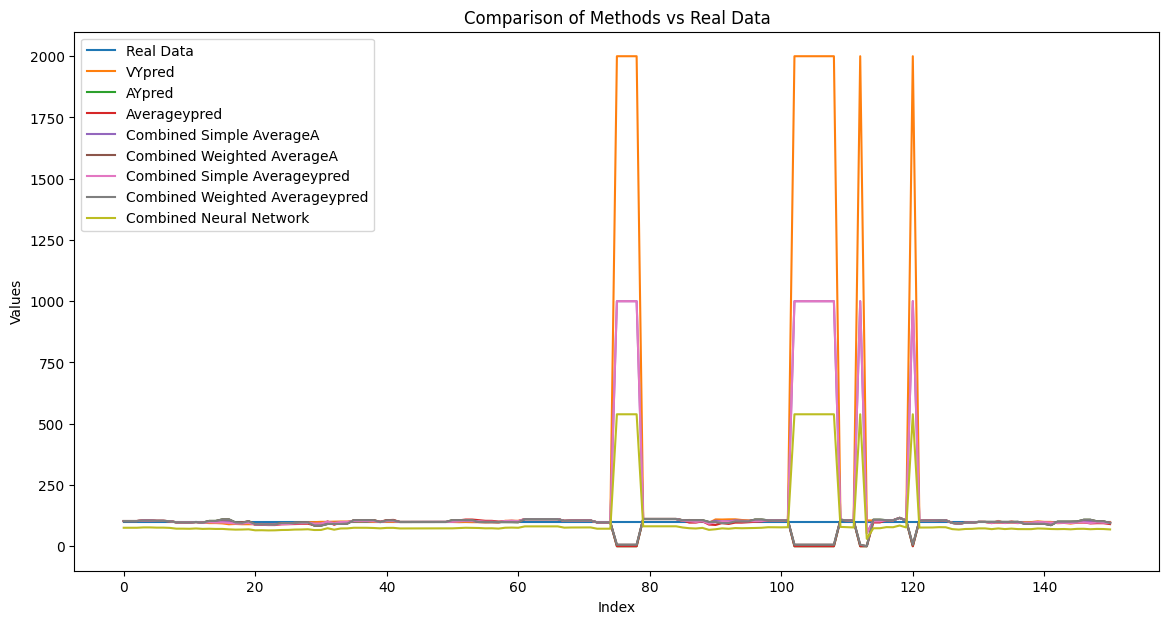

In [ ]:
#final train network and other methods for combine Audio and Visual : Just for Y
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Read data from Excel file
file_path = '/content/drive/MyDrive/lipmovement/AVdata/yinputof2l2move.xlsx'  # Replace with your actual file path
df = pd.read_excel(file_path)

# Strip leading/trailing whitespace characters from column names
df.columns = df.columns.str.strip()

# Check the lengths of each array
lengths = {col: df[col].size for col in df.columns}
print("Lengths of arrays before truncation:", lengths)

# Ensure all columns have the same length
min_length = min(lengths.values())
print("Minimum length:", min_length)

# Truncate each column to the minimum length
df = df.iloc[:min_length]

# Check the lengths again
lengths_after_truncation = {col: df[col].size for col in df.columns}
print("Lengths of arrays after truncation:", lengths_after_truncation)

# Calculate Mean Squared Error and Mean Absolute Error for both methods
mse1 = mean_squared_error(df['Yreal'], df['VYpred'])
mse2 = mean_squared_error(df['Yreal'], df['AYpred'])
mse3 = mean_squared_error(df['Yreal'], df['Averageypred'])

mae1 = mean_absolute_error(df['Yreal'], df['VYpred'])
mae2 = mean_absolute_error(df['Yreal'], df['AYpred'])
mae2 = mean_absolute_error(df['Yreal'], df['Averageypred'])

# Simple Averaging
df['Combined_Simple_AverageA'] = (df['VYpred'] + df['AYpred']) / 2
df['Combined_Simple_Averageypred'] = (df['VYpred'] + df['Averageypred']) / 2

# Calculate errors for simple averaging
mse_simple_avgA = mean_squared_error(df['Yreal'], df['Combined_Simple_AverageA'])
mse_simple_avgAV = mean_squared_error(df['Yreal'], df['Combined_Simple_Averageypred'])
mae_simple_avgA = mean_absolute_error(df['Yreal'], df['Combined_Simple_AverageA'])
mae_simple_avgAV = mean_absolute_error(df['Yreal'], df['Combined_Simple_Averageypred'])

# Weighted Averaging
weight_VYpred = 1 / mse1
weight_AYpred = 1 / mse2
weight_Averageypred = 1 / mse3
total_weightA = weight_VYpred + weight_AYpred
total_weightAV = weight_VYpred + weight_Averageypred

df['Combined_Weighted_AverageA'] = (df['VYpred'] * weight_VYpred + df['AYpred'] * weight_AYpred) / total_weightA
df['Combined_Weighted_Averageypred'] = (df['VYpred'] * weight_VYpred + df['AYpred'] * weight_Averageypred) / total_weightAV

# Calculate errors for weighted averaging
mse_weighted_avgA = mean_squared_error(df['Yreal'], df['Combined_Weighted_AverageA'])
mae_weighted_avgAV = mean_absolute_error(df['Yreal'], df['Combined_Weighted_Averageypred'])

# Define features and target
X = df[['VYpred', 'Averageypred']].values
y = df['Yreal'].values

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=100)



# Make predictions
train_predictions = model.predict(X_train).flatten()
test_predictions = model.predict(X_test).flatten()

# Evaluate the model
train_mse = mean_squared_error(y_train, train_predictions)
test_mse = mean_squared_error(y_test, test_predictions)
train_mae = mean_absolute_error(y_train, train_predictions)
test_mae = mean_absolute_error(y_test, test_predictions)

print("Train Mean Squared Error:", train_mse)
print("Test Mean Squared Error:", test_mse)
print("Train Mean Absolute Error:", train_mae)
print("Test Mean Absolute Error:", test_mae)

# Add predictions to the DataFrame
df['Combined_Neural_Network'] = model.predict(X).flatten()

# Save combined data from each method along with real data to an Excel file
combined_data_df = pd.DataFrame({
    'Yreal': df['Yreal'],
    'VYpred': df['VYpred'],
    'AYpred': df['AYpred'],
    'Averageypred': df['Averageypred'],
    'Combined_Simple_AverageA': df['Combined_Simple_AverageA'],
    'Combined_Weighted_AverageA': df['Combined_Weighted_AverageA'],
    'Combined_Simple_Averageypred': df['Combined_Simple_Averageypred'],
    'Combined_Weighted_Averageypred': df['Combined_Weighted_Averageypred'],
    'Combined_Neural_Network': df['Combined_Neural_Network'],
})

combined_data_df.to_excel('combined_yinputof2l2move.xlsx', index=False)

# Save combined error from each method along with real data to an Excel file
combined_error_df = pd.DataFrame({
    'mse_simple_avg': [mse_simple_avgA],
    'mae_simple_avg': [mae_simple_avgAV],
    'mse_weighted_avg': [mse_weighted_avgA],
    'mae_weighted_avg': [mae_weighted_avgAV],
})

combined_error_df.to_excel('error_method_data_with_nn.xlsx', index=False)

# Visualize the errors
plt.figure(figsize=(14, 7))
plt.plot(df['Yreal'], label='Real Data')
plt.plot(df['VYpred'], label='VYpred')
plt.plot(df['AYpred'], label='AYpred')
plt.plot(df['Averageypred'], label='Averageypred')
plt.plot(df['Combined_Simple_AverageA'], label='Combined Simple AverageA')
plt.plot(df['Combined_Weighted_AverageA'], label='Combined Weighted AverageA')
plt.plot(df['Combined_Simple_Averageypred'], label='Combined Simple Averageypred')
plt.plot(df['Combined_Weighted_Averageypred'], label='Combined Weighted Averageypred')
plt.plot(df['Combined_Neural_Network'], label='Combined Neural Network')
plt.legend()
plt.xlabel('Index')
plt.ylabel('Values')
plt.title('Comparison of Methods vs Real Data')
plt.show()
